# Phát hiện viêm phổi trên ảnh X-quang ngực

**Baseline — báo cáo kết quả**

Dữ liệu: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) —
5.856 ảnh X-quang ngực của trẻ 1–5 tuổi, hai lớp `NORMAL` và `PNEUMONIA`.

---

## Tóm tắt

| Hạng mục | Lựa chọn |
|---|---|
| Kiến trúc so sánh | ResNet18, DenseNet121, CNN nhỏ train từ đầu |
| Xử lý mất cân bằng | So sánh cross-entropy có và không có trọng số lớp |
| Chia dữ liệu | Cross-validation 5 fold **theo bệnh nhân**; test gốc giữ nguyên |
| Chọn checkpoint | Theo val F1, khôi phục trước khi chấm test |
| Điểm làm việc | Dò ngưỡng trên validation; báo cả ngưỡng mặc định lẫn ngưỡng dò |
| Đơn vị đánh giá | Báo cả **mức ảnh** và **mức bệnh nhân** |
| Diễn giải | Grad-CAM, đo khối lượng nhiệt ở viền, và kiểm tra che vùng |

Kết quả ở phần 3, diễn giải ở phần 4, hạn chế ở phần 5.

---

### Chuẩn bị

1. **+ Add Data** → thêm `chest-xray-pneumonia` (paultimothymooney)
2. **Settings → Accelerator** → **GPU T4**
3. **Settings → Internet** → **On** (tải ImageNet weights)

**Thời gian**: 65 phút cho 6 thí nghiệm × 5 fold trên GPU T4. Muốn nhanh thì bớt
dòng trong `EXPERIMENTS` hoặc đặt `N_FOLDS = 1`.

## Cấu hình

In [1]:
SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 15
LR            = 1e-4
WEIGHT_DECAY  = 1e-5
PATIENCE      = 5
NUM_WORKERS   = 2

N_FOLDS       = 5         # 1 = một holdout 15%; 5 = cross-validation đầy đủ
VAL_FRACTION  = 0.15      # chỉ dùng khi N_FOLDS = 1
BORDER_FRAC   = 0.15      # dùng ở phần 4.3
DETERMINISTIC = True      # cudnn tất định; chậm hơn một chút, đổi lại tái lập tốt hơn

# Hai bộ augmentation. "mạnh" mô phỏng thiết lập của các cài đặt công khai
# đạt độ đặc hiệu cao hơn: xoay 30 độ, zoom và dịch ảnh.
AUG_PRESETS = {
    "nhe":  {"rotation": 10, "scale": 0.00, "translate": 0.00, "jitter": 0.15},
    "manh": {"rotation": 30, "scale": 0.20, "translate": 0.10, "jitter": 0.20},
}

# Mỗi dòng đổi ĐÚNG MỘT yếu tố so với dòng đầu, nên chênh lệch quy được về yếu
# tố đó. Cột "hoi" ghi rõ dòng đó tồn tại để trả lời câu hỏi gì.
EXPERIMENTS = [
    {"name": "resnet18",     "arch": "resnet18",    "size": 224, "aug": "nhe",
     "balancing": "weighted", "hoi": "baseline"},
    {"name": "khong_weight", "arch": "resnet18",    "size": 224, "aug": "nhe",
     "balancing": "none",     "hoi": "trọng số lớp có cần không?"},
    {"name": "augment_manh", "arch": "resnet18",    "size": 224, "aug": "manh",
     "balancing": "weighted", "hoi": "augment mạnh có tăng độ đặc hiệu?"},
    {"name": "anh_128",      "arch": "resnet18",    "size": 128, "aug": "nhe",
     "balancing": "weighted", "hoi": "128px có mất gì so với 224px?"},
    {"name": "densenet121",  "arch": "densenet121", "size": 224, "aug": "nhe",
     "balancing": "weighted", "hoi": "mô hình lớn hơn có hơn không?"},
    {"name": "cnn_tu_dau",   "arch": "small_cnn",   "size": 150, "aug": "manh",
     "balancing": "none",     "hoi": "tái hiện CNN 150px train từ đầu"},
]

CLASSES  = ("NORMAL", "PNEUMONIA")     # NORMAL = 0, PNEUMONIA = 1 (lớp dương)
WORK_DIR = "/kaggle/working"
LOG_PATH = f"{WORK_DIR}/train_log.txt"

In [2]:
import hashlib, json, os, platform, random, re, time, warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

warnings.filterwarnings("ignore", category=UserWarning)
os.makedirs(WORK_DIR, exist_ok=True)

assert torch.cuda.is_available(), (
    "Chưa bật GPU. Settings -> Accelerator -> GPU T4, rồi Run All lại."
)
DEVICE = torch.device("cuda")

if DETERMINISTIC:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def set_seed(seed=SEED):
    """Seed mọi nguồn ngẫu nhiên mà pipeline đụng tới."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def loader_seed_args(seed=SEED):
    """generator + worker_init_fn cho DataLoader.

    Thiếu hai thứ này thì thứ tự xáo trộn và augmentation chạy trong worker vẫn
    ngẫu nhiên dù đã gọi set_seed — một lỗ hổng tái lập rất hay bị bỏ sót.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)

    def worker_init_fn(worker_id):
        worker_seed = seed + worker_id
        random.seed(worker_seed)
        np.random.seed(worker_seed)

    return {"generator": generator, "worker_init_fn": worker_init_fn}


def log(*parts):
    """In ra màn hình, đồng thời ghi vào LOG_PATH.

    Output của notebook Kaggle có thể mất chunk khi in nhanh; file thì không.
    """
    line = " ".join(str(part) for part in parts)
    print(line)
    with open(LOG_PATH, "a", encoding="utf-8") as handle:
        handle.write(line + "\n")


set_seed()

# Ghi lại phiên bản thư viện. Thiếu nó thì con số trong báo cáo không gắn được
# với môi trường đã sinh ra chúng.
VERSIONS = {
    "python": platform.python_version(), "torch": torch.__version__,
    "torchvision": torchvision.__version__, "numpy": np.__version__,
    "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
    "pillow": PIL.__version__,
}
with open(f"{WORK_DIR}/environment.json", "w") as handle:
    json.dump({**VERSIONS, "gpu": torch.cuda.get_device_name(0),
               "seed": SEED, "deterministic": DETERMINISTIC}, handle, indent=2)

log("GPU:", torch.cuda.get_device_name(0), "| deterministic:", DETERMINISTIC)
log("phiên bản:", " ".join(f"{k}={v}" for k, v in VERSIONS.items()))

GPU: Tesla T4 | deterministic: True
phiên bản: python=3.12.13 torch=2.10.0+cu128 torchvision=0.25.0+cu128 numpy=2.0.2 pandas=2.3.3 scikit-learn=1.6.1 pillow=11.3.0


---

# 1. Dữ liệu

## 1.1. Nạp dữ liệu

Kaggle mount bộ dữ liệu này theo hai kiểu đường dẫn tuỳ cách thêm. Bên trong còn
hai thứ gây sai số nếu quét thư mục ngây thơ:

- cây `chest_xray/chest_xray/` lồng bên trong, **chứa bản sao của toàn bộ ảnh**
- cây `__MACOSX/` chứa file `._*.jpeg` — không phải ảnh, nhưng có đuôi `.jpeg`
  và có đủ cấu trúc `train/NORMAL` + `train/PNEUMONIA`

In [3]:
def list_images(directory):
    """Ảnh .jpeg thật, bỏ file sidecar ._* của macOS."""
    return sorted(p for p in Path(directory).glob("*.jpeg")
                  if not p.name.startswith("._"))


def find_data_root(search_paths):
    """Thư mục chứa trực tiếp train/NORMAL và train/PNEUMONIA."""
    if isinstance(search_paths, (str, Path)):
        search_paths = [search_paths]

    candidates = []
    for base in map(Path, search_paths):
        if not base.exists():
            continue
        for train_dir in base.rglob("train"):
            if "__MACOSX" in train_dir.parts:
                continue
            if (train_dir / "NORMAL").is_dir() and (train_dir / "PNEUMONIA").is_dir():
                candidates.append(train_dir.parent)

    if not candidates:
        raise FileNotFoundError(
            f"Không tìm thấy dataset dưới {[str(p) for p in search_paths]}. "
            "Bấm '+ Add Data' và thêm 'Chest X-Ray Images (Pneumonia)'.")

    candidates = sorted(set(candidates), key=lambda path: len(path.parts))
    for candidate in candidates:
        n = len(list_images(candidate / "train" / "NORMAL"))
        mark = "  <- dùng" if candidate == candidates[0] else "  (bản trùng, bỏ qua)"
        print(f"  {candidate}  [{n} ảnh train/NORMAL]{mark}")
    return candidates[0]


DATA_ROOT = find_data_root(["/kaggle/input", "../chest_xray", "data/raw"])
log("\nDATA_ROOT =", DATA_ROOT)

  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray  [1341 ảnh train/NORMAL]  <- dùng
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray  [1341 ảnh train/NORMAL]  (bản trùng, bỏ qua)

DATA_ROOT = /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


## 1.2. Danh sách ảnh và định danh bệnh nhân

Tên file là thông tin duy nhất cho biết ảnh nào thuộc bệnh nhân nào:

| Lớp | Dạng tên |
|---|---|
| Viêm phổi | `person1_bacteria_1.jpeg`, `person1_virus_6.jpeg` |
| Bình thường | `IM-0115-0001.jpeg`, `NORMAL2-IM-1427-0001.jpeg` |

Bộ đếm `person` **không dùng chung** giữa hai phân nhóm viêm phổi: `bacteria` và
`virus` mỗi loại chạy một dãy riêng từ 1. Khoá định danh vì vậy phải gồm cả phân
nhóm — mục 1.3.4 chứng minh bằng số.

In [4]:
PNEUMONIA_RE = re.compile(r"^person(\d+)_(bacteria|virus)_", re.IGNORECASE)
NORMAL_RE    = re.compile(r"^(?:(NORMAL\d+)-)?IM-(\d+)-", re.IGNORECASE)


def parse_group_id(filename):
    """Khoá bệnh nhân suy từ tên file. Báo lỗi nếu gặp dạng tên lạ."""
    match = PNEUMONIA_RE.match(filename)
    if match:
        return f"pneumonia:{match.group(2).lower()}:{int(match.group(1))}"
    match = NORMAL_RE.match(filename)
    if match:
        return f"normal:{(match.group(1) or 'IM').lower()}:{int(match.group(2))}"
    raise ValueError(f"Tên file lạ, không suy ra được bệnh nhân: {filename}")


def build_manifest(root):
    """Một dòng cho mỗi ảnh: đường dẫn, split gốc, nhãn, bệnh nhân."""
    rows = []
    for split in ("train", "val", "test"):
        for class_id, class_name in enumerate(CLASSES):
            directory = Path(root) / split / class_name
            if not directory.is_dir():
                continue
            for path in list_images(directory):
                rows.append({
                    "path": str(path), "filename": path.name,
                    "split_original": split, "class_name": class_name,
                    "class_id": class_id, "group_id": parse_group_id(path.name)})
    if not rows:
        raise FileNotFoundError(f"Không có ảnh .jpeg nào dưới {root}")

    frame = pd.DataFrame(rows)
    frame["cache_index"] = np.arange(len(frame))   # vị trí trong cache ở mục 2.2
    return frame


manifest = build_manifest(DATA_ROOT)
log(f"{len(manifest):,} ảnh | {manifest['group_id'].nunique():,} bệnh nhân")
manifest.head(3)

5,856 ảnh | 4,097 bệnh nhân


,path,filename,split_original,class_name,class_id,group_id,cache_index
0,/kaggle/input/datasets/paultimothymooney/chest...,IM-0115-0001.jpeg,train,NORMAL,0,normal:im:115,0
1,/kaggle/input/datasets/paultimothymooney/chest...,IM-0117-0001.jpeg,train,NORMAL,0,normal:im:117,1
2,/kaggle/input/datasets/paultimothymooney/chest...,IM-0119-0001.jpeg,train,NORMAL,0,normal:im:119,2


## 1.3. Kiểm tra chất lượng dữ liệu

In [5]:
print("1.3.1  Số lượng theo split và lớp")
print("-" * 62)
print(f"{'split':<8}{'NORMAL':>9}{'PNEUMONIA':>12}{'tổng':>9}{'P/N':>7}")
for split in ("train", "val", "test"):
    subset = manifest[manifest["split_original"] == split]
    counts = subset["class_name"].value_counts()
    normal, pneumonia = int(counts.get("NORMAL", 0)), int(counts.get("PNEUMONIA", 0))
    ratio = pneumonia / normal if normal else float("nan")
    print(f"{split:<8}{normal:>9,}{pneumonia:>12,}{normal + pneumonia:>9,}{ratio:>7.2f}")
print(f"{'TỔNG':<8}{'':>9}{'':>12}{len(manifest):>9,}")

1.3.1  Số lượng theo split và lớp
--------------------------------------------------------------
split      NORMAL   PNEUMONIA     tổng    P/N
train       1,341       3,875    5,216   2.89
val             8           8       16   1.00
test          234         390      624   1.67
TỔNG                             5,856


Tập validation gốc chỉ có **16 ảnh** — quá nhỏ để chọn checkpoint, nên mục 2.1
cắt validation mới từ pool train+val.

Tỉ lệ hai lớp cũng khác nhau giữa các split: train **2,89:1** còn test **1,67:1**.
Điểm này quyết định cách đọc kết quả ở phần 3.

In [6]:
print("1.3.2  Ảnh trùng nội dung (SHA-256)")
print("-" * 62)
by_hash = defaultdict(list)
for path, split in zip(manifest["path"], manifest["split_original"]):
    by_hash[hashlib.sha256(Path(path).read_bytes()).hexdigest()].append(split)

duplicates = [s for s in by_hash.values() if len(s) > 1]
cross_split = [s for s in duplicates if len(set(s)) > 1]
print(f"tổng file             : {len(manifest):,}")
print(f"hash duy nhất         : {len(by_hash):,}")
print(f"nhóm ảnh trùng        : {len(duplicates)}")
print(f"  trong đó xuyên split: {len(cross_split)}")
print()
print("Không có ảnh y hệt nằm ở cả train lẫn test." if not cross_split
      else "CẢNH BÁO: ảnh trùng xuyên split — kết quả đánh giá bị nhiễm.")

1.3.2  Ảnh trùng nội dung (SHA-256)
--------------------------------------------------------------
tổng file             : 5,856
hash duy nhất         : 5,824
nhóm ảnh trùng        : 30
  trong đó xuyên split: 0

Không có ảnh y hệt nằm ở cả train lẫn test.


In [7]:
print("1.3.3  Định dạng, độ phân giải, tỉ lệ khung")
print("-" * 62)
modes, unreadable, dims = Counter(), 0, []
for path in manifest["path"]:
    try:
        with Image.open(path) as image:
            modes[image.mode] += 1
            dims.append(image.size)
    except OSError:
        unreadable += 1

dims = pd.DataFrame(dims, columns=["width", "height"])
dims["aspect"] = dims["width"] / dims["height"]
manifest_dims = dims                       # dùng lại ở mục 1.4

print(f"file không mở được : {unreadable}")
for mode, count in modes.most_common():
    print(f"  mode {mode:<4}       : {count:,}")
print(f"số kích thước khác : {dims.drop(columns='aspect').drop_duplicates().shape[0]:,}")
print(f"rộng  : {dims.width.min():,} – {dims.width.max():,}  (trung vị {int(dims.width.median()):,})")
print(f"cao   : {dims.height.min():,} – {dims.height.max():,}  (trung vị {int(dims.height.median()):,})")
print(f"tỉ lệ : {dims.aspect.min():.2f} – {dims.aspect.max():.2f}  (trung vị {dims.aspect.median():.2f})")
print()
print("Có cả ảnh RGB lẫn grayscale, nên pipeline ép về một kênh trước khi xử lý.")

1.3.3  Định dạng, độ phân giải, tỉ lệ khung
--------------------------------------------------------------
file không mở được : 0
  mode L          : 5,573
  mode RGB        : 283
số kích thước khác : 4,803
rộng  : 384 – 2,916  (trung vị 1,281)
cao   : 127 – 2,713  (trung vị 888)
tỉ lệ : 0.84 – 3.38  (trung vị 1.42)

Có cả ảnh RGB lẫn grayscale, nên pipeline ép về một kênh trước khi xử lý.


In [8]:
print("1.3.4  Định danh bệnh nhân và nguy cơ trùng giữa các split")
print("-" * 62)
naive_re = re.compile(r"^(person\d+)_", re.IGNORECASE)
naive, corrected = defaultdict(set), defaultdict(set)
for filename, split in zip(manifest["filename"], manifest["split_original"]):
    match = naive_re.match(filename)
    naive[match.group(1).lower() if match else filename].add(split)
    corrected[parse_group_id(filename)].add(split)

naive_span     = sum(1 for s in naive.values() if len(s) > 1)
corrected_span = sum(1 for s in corrected.values() if len(s) > 1)
print(f"khoá person<N>              : {len(naive):,} nhóm, {naive_span} nằm ở >1 split")
print(f"khoá (phân nhóm, person<N>) : {len(corrected):,} nhóm, {corrected_span} nằm ở >1 split")

subtype_ids = defaultdict(set)
for filename in manifest["filename"]:
    match = PNEUMONIA_RE.match(filename)
    if match:
        subtype_ids[match.group(2).lower()].add(int(match.group(1)))
print()
for subtype, ids in sorted(subtype_ids.items()):
    print(f"  {subtype:<9}: {len(ids):,} số, dải 1..{max(ids)}, "
          f"mật độ {len(ids) / max(ids):.3f}")
print(f"  số được dùng bởi CẢ HAI phân nhóm: "
      f"{len(subtype_ids['bacteria'] & subtype_ids['virus']):,}")

per_group = Counter(parse_group_id(f) for f in manifest["filename"])
multi = sum(1 for n in per_group.values() if n > 1)
print(f"\nbệnh nhân có >1 ảnh: {multi:,}/{len(per_group):,} "
      f"(nhiều nhất {max(per_group.values())} ảnh)")

1.3.4  Định danh bệnh nhân và nguy cơ trùng giữa các split
--------------------------------------------------------------
khoá person<N>              : 3,257 nhóm, 170 nằm ở >1 split
khoá (phân nhóm, person<N>) : 4,097 nhóm, 0 nằm ở >1 split

  bacteria : 1,437 số, dải 1..1954, mật độ 0.735
  virus    : 1,216 số, dải 1..1685, mật độ 0.722
  số được dùng bởi CẢ HAI phân nhóm: 979

bệnh nhân có >1 ảnh: 726/4,097 (nhiều nhất 30 ảnh)


Hai dãy `bacteria` và `virus` đều gần liên tục, đều bắt đầu từ 1, và có 979 số
dùng ở cả hai. Nếu bộ đếm là toàn cục thì dãy `virus` phải tránh các số đã thuộc
`bacteria`; thực tế chúng trùng nhau liên tục. Vậy `person1_bacteria` và
`person1_virus` là hai người khác nhau.

Với khoá đúng, **không bệnh nhân nào nằm ở nhiều hơn một split gốc** — tập test
gốc dùng làm holdout được.

Nhưng 726 bệnh nhân có nhiều hơn một ảnh. Điều này kéo theo hai hệ quả:
mục 2.1 phải chia validation theo bệnh nhân, và mục 3.3 phải báo cáo thêm chỉ số
ở **mức bệnh nhân** — vì ở mức ảnh, người có nhiều ảnh bị tính trọng số gấp bội.

## 1.4. Phân tích khám phá

In [9]:
C_NORMAL, C_PNEUMONIA = "#2a78d6", "#eb6834"
CLASS_COLOR = {"NORMAL": C_NORMAL, "PNEUMONIA": C_PNEUMONIA}
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e5e4e0"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "font.size": 10,
})


def tidy(ax, ygrid_only=True):
    ax.tick_params(length=0)
    ax.xaxis.grid(not ygrid_only)
    ax.yaxis.grid(ygrid_only)
    return ax

### Phân bố lớp theo split

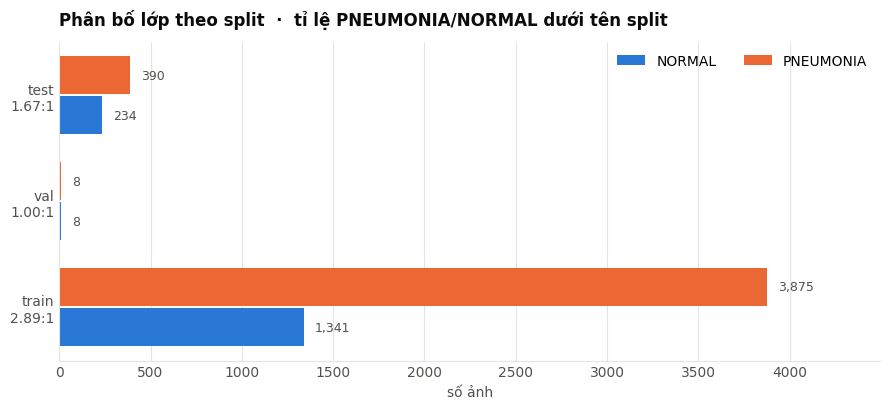

In [10]:
counts = (manifest.groupby(["split_original", "class_name"])
          .size().unstack(fill_value=0).reindex(["train", "val", "test"]))

fig, ax = plt.subplots(figsize=(9, 4.2))
y, h, gap = np.arange(len(counts)), 0.36, 0.02
for offset, cls in ((-h / 2 - gap / 2, "NORMAL"), (h / 2 + gap / 2, "PNEUMONIA")):
    bars = ax.barh(y + offset, counts[cls].values, height=h,
                   color=CLASS_COLOR[cls], label=cls)
    for rect, value in zip(bars, counts[cls].values):
        ax.text(rect.get_width() + 60, rect.get_y() + rect.get_height() / 2,
                f"{value:,}", va="center", ha="left", fontsize=9, color=INK_SOFT)

ratios = counts["PNEUMONIA"] / counts["NORMAL"].clip(lower=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n{r:.2f}:1" for s, r in ratios.items()])
ax.set_xlim(0, counts.values.max() * 1.16)
ax.set_xlabel("số ảnh")
ax.set_title("Phân bố lớp theo split  ·  tỉ lệ PNEUMONIA/NORMAL dưới tên split")
ax.legend(loc="upper right", ncol=2)
tidy(ax, ygrid_only=False)
plt.tight_layout(); plt.show()

Một mô hình đoán PNEUMONIA cho mọi ảnh đã đạt **62,5%** accuracy trên test. Nên
accuracy đơn thuần không kết luận được gì.

### Kích thước và tỉ lệ khung ảnh

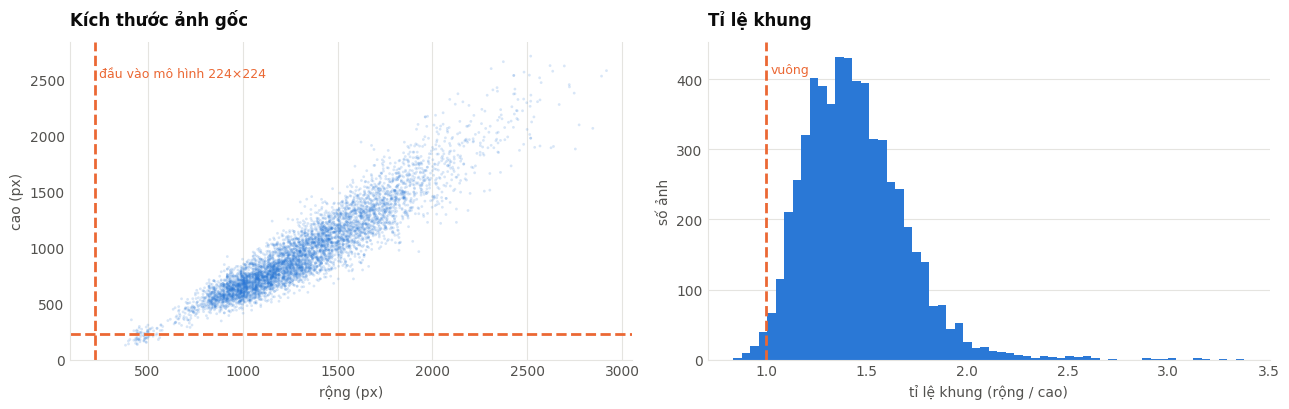

99% ảnh nằm ngang (rộng > cao).
Resize về 224×224 làm méo tỉ lệ; đây là lựa chọn có ý thức để
khớp đầu vào chuẩn của backbone ImageNet, và áp dụng đồng nhất cho mọi split.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].scatter(manifest_dims.width, manifest_dims.height, s=4, alpha=0.18,
                color=C_NORMAL, edgecolors="none")
axes[0].axvline(IMG_SIZE, color=C_PNEUMONIA, lw=2, ls="--")
axes[0].axhline(IMG_SIZE, color=C_PNEUMONIA, lw=2, ls="--")
axes[0].text(IMG_SIZE * 1.1, manifest_dims.height.max() * 0.93,
             f"đầu vào mô hình {IMG_SIZE}×{IMG_SIZE}", color=C_PNEUMONIA, fontsize=9)
axes[0].set_xlabel("rộng (px)"); axes[0].set_ylabel("cao (px)")
axes[0].set_title("Kích thước ảnh gốc")
tidy(axes[0], ygrid_only=False)

axes[1].hist(manifest_dims.aspect, bins=60, color=C_NORMAL)
axes[1].axvline(1.0, color=C_PNEUMONIA, lw=2, ls="--")
axes[1].text(1.02, axes[1].get_ylim()[1] * 0.9, "vuông", color=C_PNEUMONIA, fontsize=9)
axes[1].set_xlabel("tỉ lệ khung (rộng / cao)"); axes[1].set_ylabel("số ảnh")
axes[1].set_title("Tỉ lệ khung")
tidy(axes[1])

plt.tight_layout(); plt.show()

print(f"{(manifest_dims.aspect > 1).mean():.0%} ảnh nằm ngang (rộng > cao).")
print(f"Resize về {IMG_SIZE}×{IMG_SIZE} làm méo tỉ lệ; đây là lựa chọn có ý thức để")
print("khớp đầu vào chuẩn của backbone ImageNet, và áp dụng đồng nhất cho mọi split.")

### Ảnh mẫu

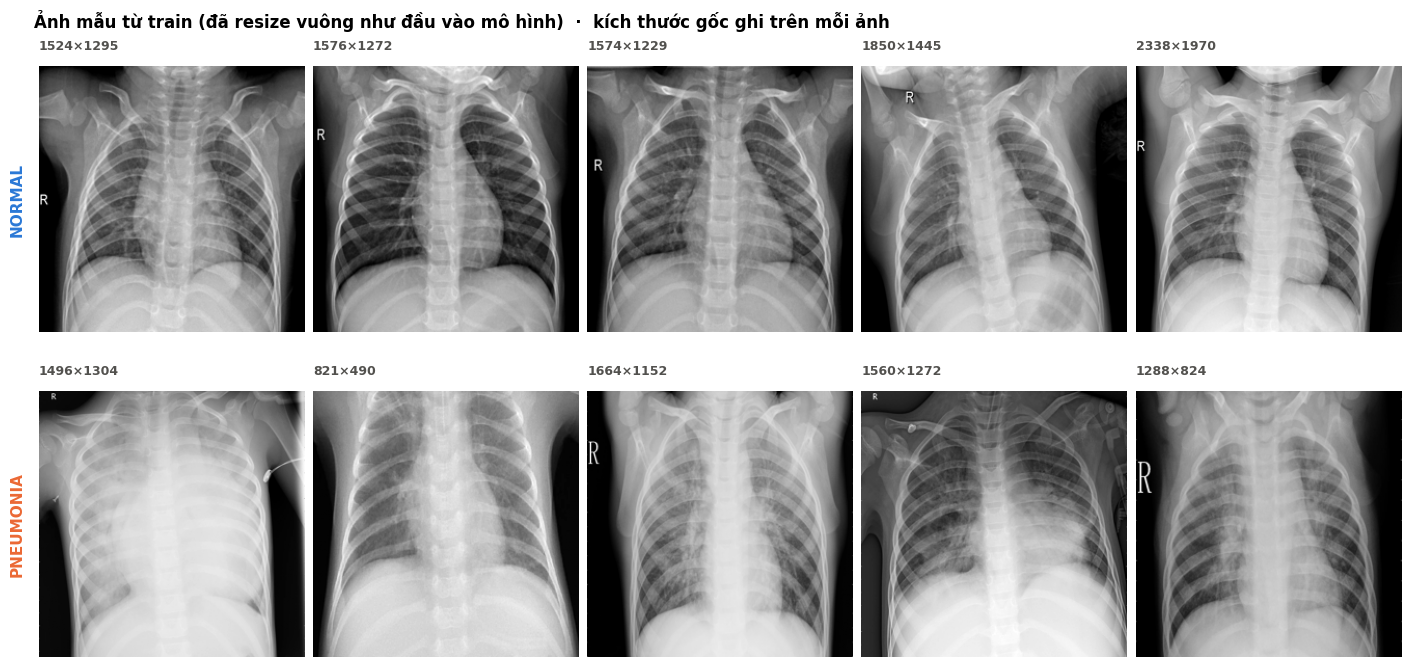

In [12]:
set_seed()
fig, axes = plt.subplots(2, 5, figsize=(14, 6.8), constrained_layout=True)
for row, cls in enumerate(CLASSES):
    pool = manifest[(manifest["split_original"] == "train")
                    & (manifest["class_name"] == cls)].sample(5, random_state=SEED)
    for col, (_, item) in enumerate(pool.iterrows()):
        with Image.open(item["path"]) as image:
            original = f"{image.size[0]}×{image.size[1]}"
            axes[row, col].imshow(image.convert("L").resize((256, 256)), cmap="gray")
        axes[row, col].set_title(original, fontsize=9, color=INK_SOFT)
        axes[row, col].axis("off")
    axes[row, 0].text(-0.08, 0.5, cls, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="center", fontsize=11,
                      fontweight="600", color=CLASS_COLOR[cls])
fig.suptitle("Ảnh mẫu từ train (đã resize vuông như đầu vào mô hình)  ·  "
             "kích thước gốc ghi trên mỗi ảnh",
             fontsize=12, fontweight="600", x=0.02, ha="left")
plt.show()

Viêm phổi biểu hiện là vùng mờ trắng ở nhu mô phổi. Đáng chú ý: hầu hết ảnh có
**ký hiệu định hướng "R"** ở góc trên — đặc trưng không mang thông tin bệnh lý
nhưng mô hình có thể bám vào. Phần 4 kiểm tra điều đó.

### Số ảnh trên mỗi bệnh nhân

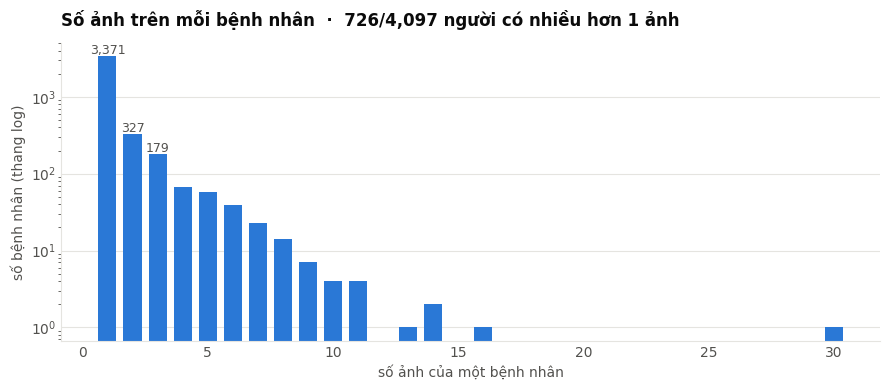

In [13]:
per_patient = manifest.groupby("group_id").size()
distribution = per_patient.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(distribution.index, distribution.values, color=C_NORMAL, width=0.72)
for rect, value in zip(bars, distribution.values):
    if value >= distribution.max() * 0.04:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() * 1.06,
                f"{value:,}", ha="center", fontsize=9, color=INK_SOFT)
ax.set_yscale("log")
ax.set_xlabel("số ảnh của một bệnh nhân")
ax.set_ylabel("số bệnh nhân (thang log)")
ax.set_title(f"Số ảnh trên mỗi bệnh nhân  ·  "
             f"{(per_patient > 1).sum():,}/{len(per_patient):,} người có nhiều hơn 1 ảnh")
tidy(ax)
plt.tight_layout(); plt.show()

### Độ sáng trung bình theo lớp

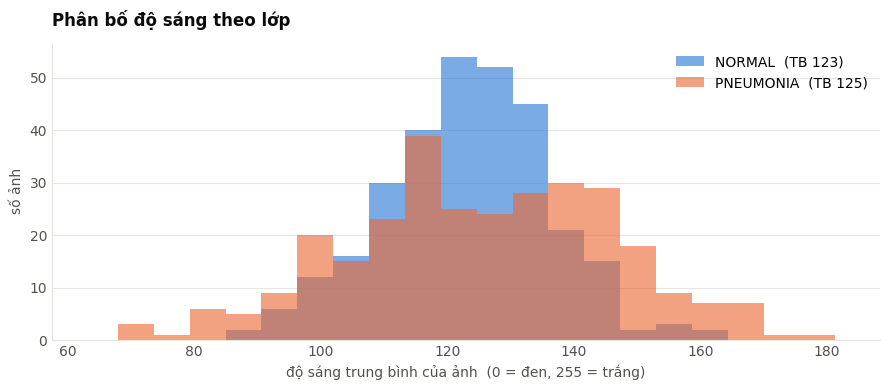

chênh lệch trung bình giữa hai lớp: 2.3 mức xám
độ lệch chuẩn trong mỗi lớp       : 16.9
Cohen's d = 0.13


In [14]:
set_seed()
train_pool = manifest[manifest["split_original"] == "train"]
sample = pd.concat([
    train_pool[train_pool["class_name"] == cls].sample(
        min(300, (train_pool["class_name"] == cls).sum()), random_state=SEED)
    for cls in CLASSES])

brightness = pd.DataFrame([
    {"class_name": item["class_name"],
     "mean": np.asarray(Image.open(item["path"]).convert("L").resize((64, 64)),
                        dtype=np.float32).mean()}
    for _, item in sample.iterrows()])

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 255, 46)
for cls in CLASSES:
    values = brightness[brightness["class_name"] == cls]["mean"]
    ax.hist(values, bins=bins, color=CLASS_COLOR[cls], alpha=0.62,
            label=f"{cls}  (TB {values.mean():.0f})")
span = brightness["mean"]
ax.set_xlim(max(0, span.min() - 12), min(255, span.max() + 12))
ax.set_xlabel("độ sáng trung bình của ảnh  (0 = đen, 255 = trắng)")
ax.set_ylabel("số ảnh")
ax.set_title("Phân bố độ sáng theo lớp")
ax.legend(loc="upper right")
tidy(ax)
plt.tight_layout(); plt.show()

delta = abs(brightness.groupby("class_name")["mean"].mean().diff().iloc[-1])
pooled = brightness.groupby("class_name")["mean"].std().mean()
print(f"chênh lệch trung bình giữa hai lớp: {delta:.1f} mức xám")
print(f"độ lệch chuẩn trong mỗi lớp       : {pooled:.1f}")
print(f"Cohen's d = {delta / pooled:.2f}")

Hai phân bố chồng lấn gần như hoàn toàn. Mô hình **không thể** phân biệt hai lớp
chỉ bằng độ sáng tổng thể. Kiểm tra này loại trừ một dạng học tắt; đặc trưng cục
bộ thì phải chờ phần 4.

---

# 2. Phương pháp

## 2.1. Chia dữ liệu

Tập test gốc giữ nguyên làm holdout: không tham gia huấn luyện, chọn checkpoint,
hay dò ngưỡng. Có **đúng một ngoại lệ**, cố ý và ghi rõ ở đây — việc chọn thí
nghiệm tốt nhất ở mục 3.4 đọc điểm trên test, nên đó là lựa chọn hậu nghiệm chứ
không phải kết quả của một quy trình mù, và phần 4 diễn giải chính mô hình được
chọn theo cách đó.

Validation cắt từ pool train+val bằng **cross-validation 5 fold chia theo bệnh
nhân** (`StratifiedGroupKFold`): mọi ảnh của một người luôn nằm cùng một phía, và
mỗi ảnh trong pool làm validation đúng một lần.

Chạy nhiều fold cho hai thứ mà một lần chia không cho được: **độ dao động** của
kết quả, và một **ngưỡng quyết định ổn định** (mục 3.4).

In [15]:
def label_split(manifest, train, val, test):
    out = manifest.copy()
    out["split"] = pd.NA
    out.loc[train.index, "split"] = "train"
    out.loc[val.index,   "split"] = "val"
    out.loc[test.index,  "split"] = "test"
    return out


def make_folds(manifest, n_folds=N_FOLDS, val_fraction=VAL_FRACTION, seed=SEED):
    """Danh sách manifest, mỗi phần tử là một fold đã gán cột split."""
    pool = manifest[manifest["split_original"].isin(["train", "val"])]
    test = manifest[manifest["split_original"] == "test"]
    n_splits = max(2, round(1 / val_fraction)) if n_folds == 1 else n_folds
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    folds = [label_split(manifest, pool.iloc[train_idx], pool.iloc[val_idx], test)
             for train_idx, val_idx in
             splitter.split(pool, pool["class_id"], groups=pool["group_id"])]
    return folds[:1] if n_folds == 1 else folds


def count_leaked_groups(split):
    """Số bệnh nhân xuất hiện ở nhiều hơn một split. Phải bằng 0."""
    return int((split.groupby("group_id")["split"].nunique() > 1).sum())


def split_summary(split):
    rows = []
    for name in ("train", "val", "test"):
        subset = split[split["split"] == name]
        counts = subset["class_name"].value_counts()
        normal, pneumonia = int(counts.get("NORMAL", 0)), int(counts.get("PNEUMONIA", 0))
        rows.append({"split": name, "NORMAL": normal, "PNEUMONIA": pneumonia,
                     "tổng": normal + pneumonia,
                     "bệnh nhân": subset["group_id"].nunique(),
                     "P/N": round(pneumonia / max(normal, 1), 2)})
    return pd.DataFrame(rows).set_index("split")


FOLDS = make_folds(manifest)
log(f"\n{len(FOLDS)} fold, chia theo bệnh nhân:")
for i, split in enumerate(FOLDS):
    s = split_summary(split)
    log(f"  fold {i}: train {s.loc['train','tổng']:>5,}  val {s.loc['val','tổng']:>4,}  "
        f"test {s.loc['test','tổng']:>4,}  |  bệnh nhân ở >1 split: "
        f"{count_leaked_groups(split)}")

print("\nChi tiết fold 0:")
display(split_summary(FOLDS[0]))


5 fold, chia theo bệnh nhân:
  fold 0: train 4,168  val 1,064  test  624  |  bệnh nhân ở >1 split: 0
  fold 1: train 4,224  val 1,008  test  624  |  bệnh nhân ở >1 split: 0
  fold 2: train 4,165  val 1,067  test  624  |  bệnh nhân ở >1 split: 0
  fold 3: train 4,190  val 1,042  test  624  |  bệnh nhân ở >1 split: 0
  fold 4: train 4,181  val 1,051  test  624  |  bệnh nhân ở >1 split: 0

Chi tiết fold 0:


,NORMAL,PNEUMONIA,tổng,bệnh nhân,P/N
split,,,,,
train,1092,3076,4168,2934,2.82
val,257,807,1064,735,3.14
test,234,390,624,428,1.67


## 2.2. Tiền xử lý và augmentation

Ảnh gốc trung bình khoảng 1,3 megapixel với kích thước rất khác nhau. Toàn bộ
được giải mã **một lần** về mảng `uint8` 224×224 giữ trong RAM (~294 MB). Nếu
giải mã lại mỗi epoch thì CPU thành nút thắt và GPU phải chờ.

Augmentation chỉ áp cho train. Validation và test dùng pipeline tất định — nếu
không, chỉ số đánh giá sẽ dao động theo nhiễu ngẫu nhiên.

In [16]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
MEAN_T = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1, 3, 1, 1)
STD_T  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1, 3, 1, 1)


def gpu_augment(batch, cfg):
    """Lật, xoay, zoom, dịch, đổi sáng/tương phản — trên GPU, riêng từng ảnh.

    Làm bằng PIL trong DataLoader thì CPU thành nút thắt: riêng RandomRotation
    và ColorJitter đã ngốn hơn 1.000 lần thời gian đọc cache. Ở đây mọi phép
    biến đổi là tensor op chạy theo lô trên GPU.

    Xoay, zoom và dịch được gộp vào MỘT phép biến đổi affine, nên chỉ nội suy
    một lần thay vì ba lần chồng lên nhau.
    """
    n, dev = batch.size(0), batch.device
    flip = torch.rand(n, device=dev) < 0.5
    batch = torch.where(flip.view(-1, 1, 1, 1), batch.flip(-1), batch)

    rand = lambda: torch.rand(n, device=dev) * 2 - 1          # noqa: E731  -1..1
    angles = rand() * (cfg["rotation"] * np.pi / 180)
    zoom = 1 + rand() * cfg["scale"]
    cos, sin = torch.cos(angles) * zoom, torch.sin(angles) * zoom
    theta = torch.zeros(n, 2, 3, device=dev)
    theta[:, 0, 0], theta[:, 0, 1] = cos, -sin
    theta[:, 1, 0], theta[:, 1, 1] = sin, cos
    theta[:, 0, 2] = rand() * cfg["translate"]
    theta[:, 1, 2] = rand() * cfg["translate"]
    grid = F.affine_grid(theta, batch.shape, align_corners=False)
    batch = F.grid_sample(batch, grid, align_corners=False, padding_mode="zeros")

    j = cfg["jitter"]
    scale = 1 + rand().view(-1, 1, 1, 1) * j
    contrast = 1 + rand().view(-1, 1, 1, 1) * j
    mean = batch.mean(dim=(1, 2, 3), keepdim=True)
    return ((batch * scale - mean) * contrast + mean).clamp(0, 1)


def to_model_input(batch_uint8, size=IMG_SIZE, aug=None):
    """(B, H, W) uint8 trên CPU  ->  (B, 3, H, W) đã chuẩn hoá trên GPU.

    Cache giữ ảnh ở IMG_SIZE; thí nghiệm nào cần kích thước khác thì thu nhỏ
    ngay trên GPU. Đây là resize hai bước (gốc -> IMG_SIZE -> size), áp dụng
    đồng nhất cho mọi split nên không tạo chênh lệch giữa train và test.
    """
    x = batch_uint8.to(DEVICE, non_blocking=True).float().div_(255).unsqueeze(1)
    if size != IMG_SIZE:
        x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
    if aug is not None:
        x = gpu_augment(x, aug)
    return (x.expand(-1, 3, -1, -1) - MEAN_T) / STD_T


def build_image_cache(manifest, size=IMG_SIZE):
    cache = np.zeros((len(manifest), size, size), dtype=np.uint8)
    for position, path in enumerate(manifest["path"]):
        with Image.open(path) as image:
            cache[position] = np.asarray(
                image.convert("L").resize((size, size), Image.BILINEAR))
        if (position + 1) % 1500 == 0:
            print(f"  {position + 1:,}/{len(manifest):,}")
    return cache


_started = time.time()
IMAGE_CACHE = build_image_cache(manifest)
log(f"cache: {IMAGE_CACHE.nbytes / 1e6:.0f} MB cho {len(manifest):,} ảnh "
    f"trong {time.time() - _started:.0f}s")


class XRayDataset(Dataset):
    """Trả về ảnh uint8 thô từ cache. Mọi biến đổi diễn ra trên GPU."""

    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        cache_index, label = self.rows[index]
        return torch.from_numpy(IMAGE_CACHE[cache_index]), label


def make_loaders(split, batch_size=BATCH_SIZE, seed=SEED):
    loaders = {}
    for name in ("train", "val", "test"):
        subset = split[split["split"] == name]
        loaders[name] = DataLoader(
            XRayDataset(list(zip(subset["cache_index"], subset["class_id"]))),
            batch_size=batch_size, shuffle=(name == "train"),
            num_workers=NUM_WORKERS, pin_memory=True,
            persistent_workers=NUM_WORKERS > 0,   # tránh sinh lại worker mỗi epoch
            **loader_seed_args(seed))
    return loaders


def class_weights_from(split):
    """Trọng số nghịch tần suất, chuẩn hoá để loss giữ nguyên thang đo."""
    counts = Counter(split[split["split"] == "train"]["class_id"])
    total = sum(counts.values())
    return torch.tensor([total / (len(CLASSES) * counts[i]) for i in range(len(CLASSES))],
                        dtype=torch.float, device=DEVICE)

  1,500/5,856
  3,000/5,856
  4,500/5,856
cache: 294 MB cho 5,856 ảnh trong 54s


## 2.3. Chỉ số đánh giá

Bài toán y tế nên bảng kết quả gồm cả nhóm chỉ số học máy lẫn nhóm quen dùng
trong lâm sàng:

| Chỉ số | Ý nghĩa | Lưu ý khi đọc |
|---|---|---|
| `accuracy` | Tỉ lệ đúng chung | Đoán bừa PNEUMONIA đã được 62,5% trên tập test này |
| `precision` | Trong số ca bị gắn nhãn bệnh, bao nhiêu đúng | **Phụ thuộc tỉ lệ mắc bệnh** của tập đang đo |
| `recall` = độ nhạy | Trong số ca bệnh thật, bắt được bao nhiêu | Bỏ sót viêm phổi là lỗi nguy hiểm nhất |
| `specificity` = độ đặc hiệu | Trong số ca lành thật, nhận đúng bao nhiêu | Phơi bày tỉ lệ báo động giả |
| `f1` | Trung bình điều hoà precision và recall | Chỉ nhìn lớp dương |
| `bal_acc` | Trung bình độ nhạy và độ đặc hiệu | Không thưởng cho mô hình đoán lệch một phía |
| `auc` | Chất lượng xếp hạng, không phụ thuộc ngưỡng | Cao mà accuracy thấp ⇒ vấn đề ở ngưỡng |
| `pr_auc` | Như trên nhưng nhìn qua precision | |

**Về precision trong bối cảnh y tế.** Precision (giá trị tiên đoán dương) thay
đổi theo tỉ lệ mắc bệnh của quần thể: cùng một mô hình đem sang nơi có tỉ lệ mắc
khác sẽ cho precision khác, dù mô hình không đổi. Tập test ở đây có **62,5% ca
bệnh** — cao hơn thực tế phòng khám rất nhiều, nên precision đo ở đây không
chuyển sang thực tế được.

Độ nhạy và độ đặc hiệu là thuộc tính của chính mô hình, không phụ thuộc tỉ lệ
mắc. Vì vậy chúng là số chính của báo cáo này, còn precision ghi kèm chú thích.

Với một công cụ **sàng lọc**, bỏ sót ca bệnh nguy hiểm hơn báo động giả, nên độ
nhạy được ưu tiên. Precision chỉ thành ràng buộc chính khi mỗi ca dương tính kéo
theo can thiệp tốn kém hoặc xâm lấn.

**Mức ảnh và mức bệnh nhân.** Tập test có 624 ảnh nhưng chỉ 428 bệnh nhân, trong
đó 82 người có nhiều hơn một ảnh. Chỉ số tính ở mức ảnh vì thế **tính trọng số
gấp bội** cho những người chụp nhiều lần. Báo cáo trình bày cả hai: mức ảnh để so
với tài liệu khác, mức bệnh nhân vì đó mới là đơn vị lâm sàng.

In [17]:
METRIC_COLS = ["accuracy", "precision", "recall", "specificity",
               "f1", "bal_acc", "auc", "pr_auc"]


def metrics_at(labels, probs, threshold=0.5):
    """Chấm điểm tại một ngưỡng. threshold=0.5 chính là argmax trên hai logit."""
    labels, probs = np.asarray(labels), np.asarray(probs)
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    sensitivity, specificity = tp / max(tp + fn, 1), tn / max(tn + fp, 1)
    return {
        "threshold": round(float(threshold), 4),
        "accuracy": float((labels == preds).mean()),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "specificity": float(specificity),
        "f1": f1_score(labels, preds, zero_division=0),
        "bal_acc": float((sensitivity + specificity) / 2),
        "auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
    }


def to_patient_level(group_ids, labels, probs):
    """Gộp dự đoán theo bệnh nhân: xác suất lấy trung bình các ảnh của người đó.

    Khoá bệnh nhân đã mang sẵn lớp trong tên nên mỗi nhóm chỉ có một nhãn.
    """
    frame = pd.DataFrame({"group": group_ids, "label": labels, "prob": probs})
    rolled = frame.groupby("group").agg(label=("label", "first"), prob=("prob", "mean"))
    return rolled["label"].to_numpy(), rolled["prob"].to_numpy()


def tune_threshold(labels, probs):
    """Ngưỡng tối đa hoá balanced accuracy. Chỉ được gọi trên validation."""
    labels, probs = np.asarray(labels), np.asarray(probs)
    candidates = np.unique(np.clip(probs, 0.001, 0.999))
    if len(candidates) > 400:
        candidates = np.quantile(candidates, np.linspace(0, 1, 400))

    scores = []
    for threshold in candidates:
        preds = (probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        scores.append((tp / max(tp + fn, 1) + tn / max(tn + fp, 1)) / 2)
    scores = np.array(scores)

    # Nhiều ngưỡng thường hoà nhau ở đỉnh. Lấy trung vị của vùng hoà thay vì
    # điểm đầu tiên, vì điểm đầu tiên luôn là ngưỡng thấp nhất trong vùng đó.
    tied = candidates[scores >= scores.max() - 1e-9]
    return float(np.median(tied)), float(scores.max())

## 2.4. Kiến trúc

| Tên | Mô tả | Tham số |
|---|---|---|
| `resnet18` | Pretrained ImageNet, fine-tune toàn bộ | 11,2 M |
| `densenet121` | Pretrained ImageNet, sâu hơn nhưng **ít tham số hơn** nhờ dùng lại đặc trưng | 7,0 M |
| `small_cnn` | 4 khối tích chập train từ đầu, không pretrained | 0,4 M |

`resnet18` và `densenet121` chạy dưới **cùng một giao thức** — cùng fold, cùng
224px, cùng augmentation nhẹ, cùng trọng số lớp — nên chênh lệch giữa hai dòng
này quy được về kiến trúc.

`small_cnn` thì không. Nó đổi cùng lúc kiến trúc, kích thước ảnh (150px),
augmentation (mạnh) và cách xử lý mất cân bằng (không trọng số), vì nó tồn tại
để **tái hiện một cấu hình công khai cụ thể** chứ không phải để cô lập yếu tố
kiến trúc. Đọc dòng đó như một mốc tham chiếu, đừng đọc như một phép so sánh
sạch — câu hỏi "đặc trưng ImageNet có giúp không" vì thế mới chỉ được trả lời
một nửa.

In [18]:
class SmallCNN(nn.Module):
    """4 khối Conv-BN-ReLU-Pool rồi gộp toàn cục. Train từ đầu."""

    def __init__(self, num_classes=len(CLASSES)):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64),
                                      block(64, 128), block(128, 256))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(arch):
    if arch == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    elif arch == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, len(CLASSES))
    elif arch == "small_cnn":
        model = SmallCNN()
    else:
        raise ValueError(f"Kiến trúc lạ: {arch!r}")
    return model.to(DEVICE)


def target_layer_for(model, arch):
    """Lớp tích chập cuối để gắn Grad-CAM. Chỉ đích danh theo kiến trúc.

    Cách dò 'Conv2d cuối cùng' sẽ sai âm thầm khi đổi kiến trúc — heatmap vẫn
    hiện ra, chỉ là hiện sai chỗ.
    """
    return {"resnet18": lambda: model.layer4[-1],
            "densenet121": lambda: model.features.denseblock4,
            "small_cnn": lambda: model.features[-1]}[arch]()


display(pd.DataFrame([
    {"thí nghiệm": s["name"], "kiến trúc": s["arch"], "px": s["size"],
     "augment": s["aug"], "balancing": s["balancing"],
     "tham số (M)": round(sum(p.numel() for p in build_model(s["arch"]).parameters())/1e6, 1),
     "câu hỏi": s["hoi"]}
    for s in EXPERIMENTS]).set_index("thí nghiệm"))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 229MB/s]


,kiến trúc,px,augment,balancing,tham số (M),câu hỏi
thí nghiệm,,,,,,
resnet18,resnet18,224,nhe,weighted,11.2,baseline
khong_weight,resnet18,224,nhe,none,11.2,trọng số lớp có cần không?
augment_manh,resnet18,224,manh,weighted,11.2,augment mạnh có tăng độ đặc hiệu?
anh_128,resnet18,128,nhe,weighted,11.2,128px có mất gì so với 224px?
densenet121,densenet121,224,nhe,weighted,7.0,mô hình lớn hơn có hơn không?
cnn_tu_dau,small_cnn,150,manh,none,0.4,tái hiện CNN 150px train từ đầu


## 2.5. Vòng huấn luyện

Adam, learning rate giảm theo `ReduceLROnPlateau` bám val F1, dừng sớm sau 5
epoch không cải thiện. Checkpoint tốt nhất theo val F1 được **khôi phục trước khi
chấm test** — nếu không, số liệu test thuộc về epoch mà vòng lặp tình cờ dừng
lại, chứ không phải mô hình đã được chọn.

In [19]:
@torch.no_grad()
def predict(model, loader, size=IMG_SIZE):
    """(nhãn thật, xác suất PNEUMONIA) trên toàn bộ loader."""
    model.eval()
    labels_all, probs_all = [], []
    for images, labels in loader:
        logits = model(to_model_input(images, size))
        probs_all += torch.softmax(logits.float(), dim=1)[:, 1].cpu().tolist()
        labels_all += labels.tolist()
    return np.array(labels_all), np.array(probs_all)


def run_fold(spec, fold_index, epochs=EPOCHS):
    log(f"\n{'=' * 62}\n{spec['name']}  |  fold {fold_index}\n{'=' * 62}")
    log(f"{spec['arch']} | {spec['size']}px | augment {spec['aug']} | "
        f"balancing {spec['balancing']}")
    set_seed(SEED + fold_index)

    split = FOLDS[fold_index]
    loaders = make_loaders(split, seed=SEED + fold_index)
    model = build_model(spec["arch"])
    size, aug = spec["size"], AUG_PRESETS[spec["aug"]]

    weights = class_weights_from(split) if spec["balancing"] == "weighted" else None
    log("trọng số lớp:", [round(w, 3) for w in weights.tolist()] if weights is not None
        else "không dùng")
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.3, patience=2)
    scaler = torch.amp.GradScaler("cuda")

    best_f1, best_epoch, best_state, stale = -1.0, 0, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, labels in loaders["train"]:
            inputs = to_model_input(images, size, aug)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                loss = criterion(model(inputs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * inputs.size(0)

        train_loss = running_loss / len(loaders["train"].dataset)
        val_labels, val_probs = predict(model, loaders["val"], size)
        val_metrics = metrics_at(val_labels, val_probs, 0.5)
        scheduler.step(val_metrics["f1"])

        marker = ""
        if val_metrics["f1"] > best_f1:
            best_f1, best_epoch, stale = val_metrics["f1"], epoch, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            marker = "  <- best"
        else:
            stale += 1

        log(f"epoch {epoch:>2}/{epochs}  loss {train_loss:.4f}  "
            f"val_f1 {val_metrics['f1']:.4f}  val_auc {val_metrics['auc']:.4f}{marker}")

        if stale >= PATIENCE:
            log(f"dừng sớm ở epoch {epoch}")
            break

    model.load_state_dict(best_state)
    log(f"khôi phục checkpoint tốt nhất (epoch {best_epoch}, val_f1 {best_f1:.4f})")

    val_labels, val_probs = predict(model, loaders["val"], size)
    test_labels, test_probs = predict(model, loaders["test"], size)
    threshold, val_score = tune_threshold(val_labels, val_probs)
    log(f"ngưỡng dò trên val: {threshold:.3f} (balanced accuracy {val_score:.4f})")

    test_groups = split[split["split"] == "test"]["group_id"].to_numpy()
    pat_labels, pat_probs = to_patient_level(test_groups, test_labels, test_probs)

    test_m = {"mặc định 0.5": metrics_at(test_labels, test_probs, 0.5),
              "đã dò":        metrics_at(test_labels, test_probs, threshold)}
    pat_m  = {"mặc định 0.5": metrics_at(pat_labels, pat_probs, 0.5),
              "đã dò":        metrics_at(pat_labels, pat_probs, threshold)}

    tag = f"{spec['name']}_fold{fold_index}"
    torch.save(best_state, f"{WORK_DIR}/{tag}.pth")
    # Ghi ngay từng fold: nếu phiên chạy bị dừng giữa chừng thì phần đã xong
    # vẫn còn, thay vì mất sạch vì bảng tổng hợp chỉ được ghi ở cuối.
    pd.DataFrame([{"thí nghiệm": spec["name"], "fold": fold_index, "đơn vị": unit,
                   "ngưỡng": mode, **{k: block[k] for k in METRIC_COLS}}
                  for unit, base in (("ảnh", test_m), ("bệnh nhân", pat_m))
                  for mode, block in base.items()]
                 ).to_csv(f"{WORK_DIR}/results_running.csv", mode="a",
                          header=not os.path.exists(f"{WORK_DIR}/results_running.csv"),
                          index=False)
    split.to_csv(f"{WORK_DIR}/manifest_fold{fold_index}.csv", index=False)

    return {
        "experiment": spec["name"], "arch": spec["arch"], "size": spec["size"],
        "balancing": spec["balancing"], "fold": fold_index,
        "model": model, "loaders": loaders, "split": split,
        "best_epoch": best_epoch, "threshold": threshold,
        "test_labels": test_labels, "test_probs": test_probs,
        "test_groups": test_groups,
        "val":           metrics_at(val_labels, val_probs, 0.5),
        "val_tuned":     metrics_at(val_labels, val_probs, threshold),
        "test":          test_m["mặc định 0.5"],
        "test_tuned":    test_m["đã dò"],
        "patient":       pat_m["mặc định 0.5"],
        "patient_tuned": pat_m["đã dò"],
    }

---

# 3. Kết quả

## 3.1. Huấn luyện

In [20]:
_t0 = time.time()
RUNS = [run_fold(spec, fold)
        for spec in EXPERIMENTS
        for fold in range(len(FOLDS))]
log(f"\ntổng thời gian: {(time.time() - _t0) / 60:.1f} phút "
    f"({len(EXPERIMENTS)} thí nghiệm × {len(FOLDS)} fold)")


resnet18  |  fold 0
resnet18 | 224px | augment nhe | balancing weighted
trọng số lớp: [1.908, 0.678]
epoch  1/15  loss 0.1224  val_f1 0.9818  val_auc 0.9980  <- best
epoch  2/15  loss 0.0803  val_f1 0.9889  val_auc 0.9983  <- best
epoch  3/15  loss 0.0533  val_f1 0.9926  val_auc 0.9992  <- best
epoch  4/15  loss 0.0427  val_f1 0.9944  val_auc 0.9992  <- best
epoch  5/15  loss 0.0457  val_f1 0.9875  val_auc 0.9993
epoch  6/15  loss 0.0274  val_f1 0.9919  val_auc 0.9993
epoch  7/15  loss 0.0254  val_f1 0.9919  val_auc 0.9992
epoch  8/15  loss 0.0178  val_f1 0.9920  val_auc 0.9996
epoch  9/15  loss 0.0137  val_f1 0.9944  val_auc 0.9997  <- best
epoch 10/15  loss 0.0088  val_f1 0.9944  val_auc 0.9997
epoch 11/15  loss 0.0116  val_f1 0.9944  val_auc 0.9997
epoch 12/15  loss 0.0065  val_f1 0.9938  val_auc 0.9997
epoch 13/15  loss 0.0061  val_f1 0.9944  val_auc 0.9997
epoch 14/15  loss 0.0054  val_f1 0.9944  val_auc 0.9997
dừng sớm ở epoch 14
khôi phục checkpoint tốt nhất (epoch 9, val_f1 0.

In [21]:
display(pd.DataFrame([
    {"thí nghiệm": r["experiment"], "fold": r["fold"],
     "epoch tốt nhất": r["best_epoch"], "val F1": round(r["val"]["f1"], 4),
     "ngưỡng": round(r["threshold"], 3)}
    for r in RUNS]).set_index(["thí nghiệm", "fold"]))

epoch tốt nhất  val F1  ngưỡng
thí nghiệm   fold                                
resnet18     0                  9  0.9944   0.900
             1                 13  0.9959   0.552
             2                 15  0.9949   0.633
             3                 10  0.9921   0.538
             4                 15  0.9968   0.624
khong_weight 0                 15  0.9944   0.748
             1                 14  0.9966   0.637
             2                  8  0.9930   0.581
             3                 12  0.9915   0.902
             4                 10  0.9962   0.585
augment_manh 0                  4  0.9881   0.496
             1                 14  0.9911   0.588
             2                 12  0.9924   0.547
             3                  4  0.9822   0.627
             4                 15  0.9923   0.565
anh_128      0                  9  0.9925   0.664
             1                 14  0.9973   0.824
             2                  8  0.9949   0.406
             3                 10  0.9915   0.462
             4                  4  0.9930   0.884
densenet121  0                  3  0.9932   0.856
             1                 14  0.9973   0.545
             2                  9  0.9943   0.381
             3                 14  0.9915   0.559
             4                 12  0.9955   0.575
cnn_tu_dau   0                 10  0.9694   0.805
             1                 11  0.9678   0.691
             2                 12  0.9734   0.515
             3                 13  0.9678   0.598
             4                 14  0.9744   0.559

## 3.2. So sánh các thí nghiệm

Mọi con số dưới đây đo trên **cùng một tập test gốc**, nên chênh lệch quy được về
kiến trúc hoặc cách xử lý mất cân bằng. `± std` là dao động qua các fold.

In [22]:
per_fold = pd.DataFrame([
    {"thí nghiệm": r["experiment"], "fold": r["fold"], "đơn vị": unit,
     "ngưỡng": mode, **{k: r[key][k] for k in METRIC_COLS}}
    for r in RUNS
    for unit, base in (("ảnh", "test"), ("bệnh nhân", "patient"))
    for mode, key in (("mặc định 0.5", base), ("đã dò", f"{base}_tuned"))])
per_fold.to_csv(f"{WORK_DIR}/results_per_fold.csv", index=False)


def summarise(frame, keys, columns=METRIC_COLS):
    grouped = frame.groupby(keys)[list(columns)]
    mean, std = grouped.mean().round(4), grouped.std().round(4).fillna(0)
    return mean if len(FOLDS) == 1 else mean.astype(str) + " ± " + std.astype(str)


print("MỨC ẢNH — trung bình qua các fold\n")
display(summarise(per_fold[per_fold["đơn vị"] == "ảnh"], ["thí nghiệm", "ngưỡng"]))

MỨC ẢNH — trung bình qua các fold



accuracy        precision           recall  \
thí nghiệm   ngưỡng                                                            
anh_128      mặc định 0.5  0.8413 ± 0.0188  0.7989 ± 0.0191  0.9979 ± 0.0011   
             đã dò          0.859 ± 0.0141  0.8181 ± 0.0165  0.9964 ± 0.0023   
augment_manh mặc định 0.5  0.9144 ± 0.0069  0.8839 ± 0.0114  0.9938 ± 0.0043   
             đã dò           0.9186 ± 0.01    0.89 ± 0.0168  0.9928 ± 0.0064   
cnn_tu_dau   mặc định 0.5  0.7981 ± 0.0257  0.7623 ± 0.0258  0.9856 ± 0.0107   
             đã dò         0.8301 ± 0.0207  0.8036 ± 0.0266  0.9656 ± 0.0143   
densenet121  mặc định 0.5   0.8494 ± 0.026  0.8089 ± 0.0277  0.9954 ± 0.0028   
             đã dò         0.8612 ± 0.0172  0.8219 ± 0.0194  0.9938 ± 0.0034   
khong_weight mặc định 0.5   0.8388 ± 0.016  0.7962 ± 0.0161  0.9979 ± 0.0011   
             đã dò           0.859 ± 0.011  0.8177 ± 0.0126  0.9969 ± 0.0021   
resnet18     mặc định 0.5  0.8513 ± 0.0185    0.8103 ± 0.02  0.9959 ± 0.0023   
             đã dò         0.8635 ± 0.0169  0.8235 ± 0.0185  0.9954 ± 0.0021   

                               specificity               f1          bal_acc  \
thí nghiệm   ngưỡng                                                            
anh_128      mặc định 0.5  0.5803 ± 0.0505  0.8873 ± 0.0118  0.7891 ± 0.0251   
             đã dò         0.6299 ± 0.0411   0.8984 ± 0.009  0.8132 ± 0.0195   
augment_manh mặc định 0.5  0.7821 ± 0.0251  0.9356 ± 0.0047  0.8879 ± 0.0106   
             đã dò          0.7949 ± 0.036  0.9385 ± 0.0068  0.8938 ± 0.0151   
cnn_tu_dau   mặc định 0.5  0.4855 ± 0.0762   0.8594 ± 0.015  0.7356 ± 0.0356   
             đã dò         0.6043 ± 0.0697  0.8768 ± 0.0124   0.785 ± 0.0301   
densenet121  mặc định 0.5   0.606 ± 0.0722  0.8923 ± 0.0163  0.8007 ± 0.0352   
             đã dò         0.6402 ± 0.0497  0.8996 ± 0.0109   0.817 ± 0.0237   
khong_weight mặc định 0.5  0.5735 ± 0.0423    0.8856 ± 0.01  0.7857 ± 0.0212   
             đã dò         0.6291 ± 0.0319   0.8984 ± 0.007   0.813 ± 0.0152   
resnet18     mặc định 0.5  0.6103 ± 0.0518  0.8934 ± 0.0117  0.8031 ± 0.0252   
             đã dò         0.6436 ± 0.0465  0.9012 ± 0.0108  0.8195 ± 0.0228   

                                       auc           pr_auc  
thí nghiệm   ngưỡng                                          
anh_128      mặc định 0.5  0.9579 ± 0.0129  0.9667 ± 0.0137  
             đã dò         0.9579 ± 0.0129  0.9667 ± 0.0137  
augment_manh mặc định 0.5   0.9802 ± 0.002  0.9852 ± 0.0019  
             đã dò          0.9802 ± 0.002  0.9852 ± 0.0019  
cnn_tu_dau   mặc định 0.5   0.9198 ± 0.009  0.9402 ± 0.0074  
             đã dò          0.9198 ± 0.009  0.9402 ± 0.0074  
densenet121  mặc định 0.5  0.9557 ± 0.0095  0.9578 ± 0.0122  
             đã dò         0.9557 ± 0.0095  0.9578 ± 0.0122  
khong_weight mặc định 0.5  0.9584 ± 0.0044  0.9652 ± 0.0044  
             đã dò         0.9584 ± 0.0044  0.9652 ± 0.0044  
resnet18     mặc định 0.5   0.9586 ± 0.005  0.9652 ± 0.0068  
             đã dò          0.9586 ± 0.005  0.9652 ± 0.0068

### Trả lời năm câu hỏi

Số dưới đây lấy từ bảng ngay trên: **mức ảnh, ngưỡng mặc định 0,5, trung bình ±
độ lệch chuẩn qua 5 fold**. Mốc so sánh luôn là dòng `resnet18`.

| Câu hỏi | Trả lời | Bằng chứng |
|---|---|---|
| Trọng số lớp có cần không? | Có, nhưng yếu | `bal_acc` 0,803 so với 0,786; độ đặc hiệu 0,610 so với 0,574. Chênh lệch (+0,037) **nhỏ hơn** dao động giữa các fold (±0,052) — chưa đủ để kết luận chắc |
| Augment mạnh có tăng độ đặc hiệu? | **Có, rõ rệt** | Độ đặc hiệu 0,610 → **0,782** (+0,172), `bal_acc` 0,803 → 0,888, AUC 0,959 → 0,980. Độ nhạy gần như không đổi (0,996 → 0,994) |
| 128px có mất gì so với 224px? | Mất nhẹ | `bal_acc` 0,803 → 0,789, độ đặc hiệu 0,610 → 0,580. Nhưng **AUC gần như không đổi** (0,9586 → 0,9579): khả năng xếp hạng còn nguyên, mất mát nằm ở điểm làm việc |
| Mô hình sâu hơn có hơn không? | Không | `densenet121` `bal_acc` 0,801 ± 0,035 so với 0,803 ± 0,025 — trùng nhau, và còn dao động mạnh hơn |
| Tái hiện được CNN 150px train từ đầu? | **Không** | Cấu hình công khai báo accuracy 0,926 / độ đặc hiệu 0,876; ở đây được 0,798 ± 0,026 / 0,486 ± 0,076. Khoảng cách quá lớn để quy về nhiễu |

Kết quả đáng giá nhất của cả run là dòng thứ hai. `augment_manh` đổi **đúng một
yếu tố** so với baseline — xoay 30° thay vì 10°, thêm zoom và dịch ảnh — và đổi
lại 0,172 độ đặc hiệu mà không mất độ nhạy. Biên độ đó gấp hơn ba lần dao động
giữa các fold, và lặp lại ở cả 5 fold.

### Vì sao không thể chọn thí nghiệm bằng validation

`augment_manh` có **val F1 thấp nhất** trong bốn cấu hình `resnet18` — thấp hơn
baseline ở cả 5 fold (0,988 / 0,991 / 0,992 / 0,982 / 0,992 so với 0,994 / 0,996
/ 0,995 / 0,992 / 0,997) — trong khi test tốt hơn hẳn. Nếu chọn theo val, cấu
hình tốt nhất của run này đã bị loại.

Gốc rễ là khoảng cách giữa hai tập. Với baseline, balanced accuracy trên
validation trung bình **0,994** qua 5 fold (xem `train_log.txt`); cùng chỉ số đó
trên test chỉ còn **0,820**. `bal_acc` và
độ đặc hiệu **không phụ thuộc tỉ lệ mắc bệnh**, nên chênh lệch này *không* giải
thích được bằng việc test có tỉ lệ lớp khác — lập luận ở mục 2.3 chỉ áp cho
precision. Còn lại hai khả năng mà run này chưa tách được:

- **Lệch phân bố** giữa pool train+val và thư mục test gốc, nhiều khả năng do
  khác đợt thu thập.
- **Rò rỉ còn sót trong pool.** Mục 1.3.2 xác nhận không có ảnh trùng nào nằm
  xuyên split *gốc*, nhưng 30 nhóm ảnh trùng nội dung nằm trong pool chưa được
  kiểm lại sau khi chia 5 fold: hai bản sao hoàn toàn có thể rơi vào train và val
  của cùng một fold.

Hệ quả cần nhớ khi đọc phần còn lại: **validation ở đây không phải proxy cho
test**. Checkpoint được chọn theo nó, ngưỡng được dò trên nó — cả hai vì thế đều
kém tin cậy hơn con số 0,99 gợi ra.

## 3.3. Mức ảnh so với mức bệnh nhân

Tập test có 624 ảnh nhưng chỉ 428 bệnh nhân. Ở mức ảnh, người chụp nhiều lần được
tính trọng số gấp bội — mức bệnh nhân sửa điều đó bằng cách lấy trung bình xác
suất các ảnh của cùng một người rồi mới quyết định.

In [23]:
print("MỨC BỆNH NHÂN — trung bình qua các fold\n")
display(summarise(per_fold[per_fold["đơn vị"] == "bệnh nhân"],
                  ["thí nghiệm", "ngưỡng"]))

print("\nChênh lệch (mức bệnh nhân − mức ảnh), ngưỡng mặc định:\n")
default_only = per_fold[per_fold["ngưỡng"] == "mặc định 0.5"]
pivot = default_only.pivot_table(index="thí nghiệm", columns="đơn vị",
                                 values=["bal_acc", "specificity", "recall"])
delta = pd.DataFrame({
    metric: (pivot[(metric, "bệnh nhân")] - pivot[(metric, "ảnh")]).round(4)
    for metric in ("bal_acc", "specificity", "recall")})
display(delta)

MỨC BỆNH NHÂN — trung bình qua các fold



accuracy        precision           recall  \
thí nghiệm   ngưỡng                                                            
anh_128      mặc định 0.5  0.7771 ± 0.0255   0.682 ± 0.0247  0.9961 ± 0.0022   
             đã dò          0.8056 ± 0.022  0.7114 ± 0.0242     0.9951 ± 0.0   
augment_manh mặc định 0.5   0.886 ± 0.0132   0.809 ± 0.0182     0.9951 ± 0.0   
             đã dò         0.8921 ± 0.0181   0.8184 ± 0.027  0.9941 ± 0.0022   
cnn_tu_dau   mặc định 0.5  0.7229 ± 0.0371  0.6351 ± 0.0322   0.9852 ± 0.007   
             đã dò          0.7771 ± 0.031  0.6892 ± 0.0345  0.9714 ± 0.0095   
densenet121  mặc định 0.5   0.793 ± 0.0374  0.6992 ± 0.0377     0.9951 ± 0.0   
             đã dò         0.8098 ± 0.0245  0.7164 ± 0.0261  0.9941 ± 0.0022   
khong_weight mặc định 0.5  0.7748 ± 0.0207  0.6795 ± 0.0201  0.9961 ± 0.0022   
             đã dò          0.8023 ± 0.016  0.7076 ± 0.0173  0.9951 ± 0.0035   
resnet18     mặc định 0.5  0.7935 ± 0.0265  0.6988 ± 0.0269     0.9951 ± 0.0   
             đã dò         0.8103 ± 0.0239  0.7165 ± 0.0252     0.9951 ± 0.0   

                               specificity               f1          bal_acc  \
thí nghiệm   ngưỡng                                                            
anh_128      mặc định 0.5  0.5796 ± 0.0489  0.8094 ± 0.0174  0.7878 ± 0.0242   
             đã dò         0.6347 ± 0.0419  0.8295 ± 0.0163  0.8149 ± 0.0209   
augment_manh mặc định 0.5   0.7876 ± 0.025  0.8923 ± 0.0111  0.8913 ± 0.0125   
             đã dò             0.8 ± 0.036  0.8975 ± 0.0154   0.897 ± 0.0171   
cnn_tu_dau   mặc định 0.5  0.4862 ± 0.0739  0.7719 ± 0.0229  0.7357 ± 0.0351   
             đã dò         0.6018 ± 0.0665  0.8058 ± 0.0206  0.7866 ± 0.0291   
densenet121  mặc định 0.5  0.6107 ± 0.0712  0.8208 ± 0.0263  0.8029 ± 0.0356   
             đã dò         0.6436 ± 0.0476  0.8325 ± 0.0175  0.8188 ± 0.0232   
khong_weight mặc định 0.5  0.5751 ± 0.0392  0.8077 ± 0.0143  0.7856 ± 0.0197   
             đã dò         0.6284 ± 0.0315   0.827 ± 0.0115  0.8118 ± 0.0152   
resnet18     mặc định 0.5  0.6116 ± 0.0503  0.8208 ± 0.0187  0.8033 ± 0.0252   
             đã dò         0.6436 ± 0.0455  0.8329 ± 0.0172  0.8193 ± 0.0227   

                                       auc           pr_auc  
thí nghiệm   ngưỡng                                          
anh_128      mặc định 0.5  0.9495 ± 0.0119  0.9302 ± 0.0201  
             đã dò         0.9495 ± 0.0119  0.9302 ± 0.0201  
augment_manh mặc định 0.5  0.9747 ± 0.0024   0.963 ± 0.0055  
             đã dò         0.9747 ± 0.0024   0.963 ± 0.0055  
cnn_tu_dau   mặc định 0.5  0.9089 ± 0.0061   0.8686 ± 0.012  
             đã dò         0.9089 ± 0.0061   0.8686 ± 0.012  
densenet121  mặc định 0.5  0.9551 ± 0.0069   0.931 ± 0.0139  
             đã dò         0.9551 ± 0.0069   0.931 ± 0.0139  
khong_weight mặc định 0.5  0.9533 ± 0.0054  0.9321 ± 0.0075  
             đã dò         0.9533 ± 0.0054  0.9321 ± 0.0075  
resnet18     mặc định 0.5   0.9531 ± 0.003  0.9322 ± 0.0066  
             đã dò          0.9531 ± 0.003  0.9322 ± 0.0066


Chênh lệch (mức bệnh nhân − mức ảnh), ngưỡng mặc định:



,bal_acc,specificity,recall
thí nghiệm,,,
anh_128,-0.0013,-0.0008,-0.0019
augment_manh,0.0034,0.0055,0.0012
cnn_tu_dau,0.0002,0.0008,-0.0004
densenet121,0.0022,0.0047,-0.0003
khong_weight,-0.0001,0.0016,-0.0019
resnet18,0.0002,0.0013,-0.0008


## 3.4. Ensemble và điểm làm việc

`argmax` trên hai logit tương đương ngưỡng cứng **0,5**. Ngưỡng đó hợp với tỉ lệ
lớp lúc huấn luyện (2,89:1) nhưng tập test có tỉ lệ khác (1,67:1), nên nó không
nhất thiết là điểm làm việc tốt nhất.

Ngưỡng được dò trên **validation**, không bao giờ trên test. Vì validation lấy từ
cùng phân bố với train còn test thì khác, ngưỡng dò được là điểm khởi đầu có cơ sở
chứ không phải bảo đảm — nên báo cáo trình bày cả hai. Độ tản mát giữa các fold
cho biết ngưỡng ổn định tới đâu.

In [24]:
def show_confusion(title, matrix):
    (tn, fp), (fn, tp) = matrix
    sensitivity, specificity = tp / max(tp + fn, 1), tn / max(tn + fp, 1)
    precision = tp / max(tp + fp, 1)
    print(f"\n{title}  (n={tn + fp + fn + tp})")
    print(f"  TN {tn:>4}   FP {fp:>4}")
    print(f"  FN {fn:>4}   TP {tp:>4}")
    print(f"  bỏ sót {fn}/{fn + tp} ca viêm phổi  → độ nhạy {sensitivity:.1%}")
    print(f"  báo nhầm {fp}/{tn + fp} ca bình thường → độ đặc hiệu {specificity:.1%}")
    print(f"  precision {precision:.1%}  |  balanced accuracy "
          f"{(sensitivity + specificity) / 2:.1%}")


# Trung bình xác suất các fold: thường tốt hơn mọi fold đơn lẻ, không tốn thêm
# chi phí huấn luyện.
ENSEMBLE = {}
for spec in EXPERIMENTS:
    runs = [r for r in RUNS if r["experiment"] == spec["name"]]
    labels = runs[0]["test_labels"]
    probs = np.mean([r["test_probs"] for r in runs], axis=0)
    threshold = float(np.median([r["threshold"] for r in runs]))
    pat_labels, pat_probs = to_patient_level(runs[0]["test_groups"], labels, probs)
    ENSEMBLE[spec["name"]] = {
        "threshold": threshold, "labels": labels, "probs": probs,
        "ảnh / mặc định 0.5":       metrics_at(labels, probs, 0.5),
        "ảnh / đã dò":              metrics_at(labels, probs, threshold),
        "bệnh nhân / mặc định 0.5": metrics_at(pat_labels, pat_probs, 0.5),
        "bệnh nhân / đã dò":        metrics_at(pat_labels, pat_probs, threshold)}

print("ENSEMBLE — trung bình xác suất các fold\n")
display(pd.DataFrame([
    {"thí nghiệm": name, "cách chấm": key,
     **{k: round(entry[key][k], 4) for k in METRIC_COLS}}
    for name, entry in ENSEMBLE.items()
    for key in ("ảnh / mặc định 0.5", "ảnh / đã dò",
                "bệnh nhân / mặc định 0.5", "bệnh nhân / đã dò")
]).set_index(["thí nghiệm", "cách chấm"]))

print("\nNgưỡng theo fold:")
for spec in EXPERIMENTS:
    values = [r["threshold"] for r in RUNS if r["experiment"] == spec["name"]]
    extra = (f"  trung vị {np.median(values):.3f}  sd {np.std(values):.3f}"
             if len(values) > 1 else "")
    print(f"  {spec['name']:<22} {[round(v, 3) for v in values]}{extra}")

BEST = max(ENSEMBLE, key=lambda n: ENSEMBLE[n]["bệnh nhân / đã dò"]["bal_acc"])
print(f"\nTốt nhất theo balanced accuracy mức bệnh nhân: {BEST}")
show_confusion(f"{BEST} — TEST mức ảnh @ 0.5 (ensemble)",
               ENSEMBLE[BEST]["ảnh / mặc định 0.5"]["confusion_matrix"])
show_confusion(f"{BEST} — TEST mức bệnh nhân @ "
               f"{ENSEMBLE[BEST]['threshold']:.3f} (ensemble)",
               ENSEMBLE[BEST]["bệnh nhân / đã dò"]["confusion_matrix"])

ENSEMBLE — trung bình xác suất các fold



accuracy  precision  recall  \
thí nghiệm   cách chấm                                               
resnet18     ảnh / mặc định 0.5          0.8622     0.8207  0.9974   
             ảnh / đã dò                 0.8766     0.8366  0.9974   
             bệnh nhân / mặc định 0.5    0.8037     0.7088  0.9951   
             bệnh nhân / đã dò           0.8248     0.7319  0.9951   
khong_weight ảnh / mặc định 0.5          0.8429     0.8004  0.9974   
             ảnh / đã dò                 0.8638     0.8224  0.9974   
             bệnh nhân / mặc định 0.5    0.7780     0.6824  0.9951   
             bệnh nhân / đã dò           0.8084     0.7138  0.9951   
augment_manh ảnh / mặc định 0.5          0.9231     0.8940  0.9949   
             ảnh / đã dò                 0.9311     0.9044  0.9949   
             bệnh nhân / mặc định 0.5    0.8972     0.8245  0.9951   
             bệnh nhân / đã dò           0.9089     0.8417  0.9951   
anh_128      ảnh / mặc định 0.5          0.8510     0.8087  0.9974   
             ảnh / đã dò                 0.8686     0.8277  0.9974   
             bệnh nhân / mặc định 0.5    0.7874     0.6918  0.9951   
             bệnh nhân / đã dò           0.8178     0.7240  0.9951   
densenet121  ảnh / mặc định 0.5          0.8526     0.8104  0.9974   
             ảnh / đã dò                 0.8606     0.8189  0.9974   
             bệnh nhân / mặc định 0.5    0.7944     0.6990  0.9951   
             bệnh nhân / đã dò           0.8061     0.7113  0.9951   
cnn_tu_dau   ảnh / mặc định 0.5          0.8093     0.7683  0.9949   
             ảnh / đã dò                 0.8269     0.7925  0.9795   
             bệnh nhân / mặc định 0.5    0.7290     0.6381  0.9901   
             bệnh nhân / đã dò           0.7687     0.6757  0.9852   

                                       specificity      f1  bal_acc     auc  \
thí nghiệm   cách chấm                                                        
resnet18     ảnh / mặc định 0.5             0.6368  0.9005   0.8171  0.9657   
             ảnh / đã dò                    0.6752  0.9099   0.8363  0.9657   
             bệnh nhân / mặc định 0.5       0.6311  0.8279   0.8131  0.9612   
             bệnh nhân / đã dò              0.6711  0.8434   0.8331  0.9612   
khong_weight ảnh / mặc định 0.5             0.5855  0.8881   0.7915  0.9659   
             ảnh / đã dò                    0.6410  0.9015   0.8192  0.9659   
             bệnh nhân / mặc định 0.5       0.5822  0.8096   0.7886  0.9625   
             bệnh nhân / đã dò              0.6400  0.8313   0.8175  0.9625   
augment_manh ảnh / mặc định 0.5             0.8034  0.9417   0.8991  0.9823   
             ảnh / đã dò                    0.8248  0.9475   0.9098  0.9823   
             bệnh nhân / mặc định 0.5       0.8089  0.9018   0.9020  0.9778   
             bệnh nhân / đã dò              0.8311  0.9120   0.9131  0.9778   
anh_128      ảnh / mặc định 0.5             0.6068  0.8932   0.8021  0.9678   
             ảnh / đã dò                    0.6538  0.9047   0.8256  0.9678   
             bệnh nhân / mặc định 0.5       0.6000  0.8162   0.7975  0.9591   
             bệnh nhân / đã dò              0.6578  0.8382   0.8264  0.9591   
densenet121  ảnh / mặc định 0.5             0.6111  0.8943   0.8043  0.9653   
             ảnh / đã dò                    0.6325  0.8994   0.8150  0.9653   
             bệnh nhân / mặc định 0.5       0.6133  0.8211   0.8042  0.9635   
             bệnh nhân / đã dò              0.6356  0.8296   0.8153  0.9635   
cnn_tu_dau   ảnh / mặc định 0.5             0.5000  0.8670   0.7474  0.9236   
             ảnh / đã dò                    0.5726  0.8761   0.7761  0.9236   
             bệnh nhân / mặc định 0.5       0.4933  0.7761   0.7417  0.9137   
             bệnh nhân / đã dò              0.5733  0.8016   0.7793  0.9137   

                                       pr_auc  
thí nghiệm   cách chấm                         
resnet18     ảnh / mặc định 0.5        0.9706  
             ảnh / 


Ngưỡng theo fold:
  resnet18               [0.9, 0.552, 0.633, 0.538, 0.624]  trung vị 0.624  sd 0.131
  khong_weight           [0.748, 0.637, 0.581, 0.902, 0.585]  trung vị 0.637  sd 0.121
  augment_manh           [0.496, 0.588, 0.547, 0.627, 0.565]  trung vị 0.565  sd 0.043
  anh_128                [0.664, 0.824, 0.406, 0.462, 0.884]  trung vị 0.664  sd 0.190
  densenet121            [0.856, 0.545, 0.381, 0.559, 0.575]  trung vị 0.559  sd 0.153
  cnn_tu_dau             [0.805, 0.691, 0.515, 0.598, 0.559]  trung vị 0.598  sd 0.104

Tốt nhất theo balanced accuracy mức bệnh nhân: augment_manh

augment_manh — TEST mức ảnh @ 0.5 (ensemble)  (n=624)
  TN  188   FP   46
  FN    2   TP  388
  bỏ sót 2/390 ca viêm phổi  → độ nhạy 99.5%
  báo nhầm 46/234 ca bình thường → độ đặc hiệu 80.3%
  precision 89.4%  |  balanced accuracy 89.9%

augment_manh — TEST mức bệnh nhân @ 0.565 (ensemble)  (n=428)
  TN  187   FP   38
  FN    1   TP  202
  bỏ sót 1/203 ca viêm phổi  → độ nhạy 99.5%
  báo nhầm 38

## 3.5. Đối chiếu với các kết quả công khai

Bảng dưới chỉ đặt cạnh nhau những nguồn **đánh giá trên đúng tập test gốc**
(234 NORMAL / 390 PNEUMONIA). Con số nào đo trên tập khác thì không so được,
và được tách riêng ở dưới.

| Nguồn | Cách làm | Accuracy | Độ đặc hiệu |
|---|---|---|---|
| CNN Keras 150px, 12 epoch | train từ đầu, augment mạnh | 0,926 | 0,876 |
| **Báo cáo này** | xem bảng mục 3.2 | | |
| EfficientNet-B0, 4 epoch | không có validation set | 0,804 | 0,480 |
| CNN tự xây 244px, 10 epoch | split gốc | 0,770 | 0,420 |

Hai kết quả công bố cao hơn nhưng **đã đổi tập đánh giá**, nên không nằm cùng
thang đo:

| Nguồn | Accuracy công bố | Vì sao không so được |
|---|---|---|
| Slimi et al. 2025 (SNN+GRU+CNN) | 0,9935 | Confusion matrix của bài có 1.550 mẫu, gần cân bằng (771/779), trong khi test gốc chỉ có 624 mẫu lệch 1,67:1. Con số khớp với việc chạy SMOTE trên toàn bộ dữ liệu **rồi mới chia** 80/20 — tập test khi đó chứa mẫu tổng hợp nội suy từ chính ảnh trong tập train |
| Repo ResNet50 2 pha | 0,956 | Thêm khoảng 700 ảnh normal từ nguồn khác rồi chia lại 70-15-15 |

Điểm chung của mọi nguồn dùng test gốc: **độ nhạy rất cao (~0,99) nhưng độ đặc
hiệu thấp** (0,42–0,88). Đây là đặc điểm của bài toán trên bộ dữ liệu này, không
phải lỗi của một cài đặt cụ thể.

---

# 4. Diễn giải mô hình

Chỉ số cao chưa đủ để tin một mô hình y tế. Grad-CAM cho thấy vùng ảnh mô hình
dựa vào; nếu vùng đó không phải nhu mô phổi thì kết quả tốt là do trùng hợp chứ
không do học được dấu hiệu bệnh.

Dùng mô hình tốt nhất ở mục 3.4, fold 0, đọc dự đoán ở đúng ngưỡng đã báo cáo.

In [25]:
class GradCAM:
    """Grad-CAM bằng hook trên một lớp tích chập.

    Mỗi kênh đặc trưng được đánh trọng số bằng gradient trung bình của nó với
    logit mục tiêu, cộng lại rồi lấy phần dương.
    """

    def __init__(self, model, target_layer):
        self.model, self.activations, self.gradients = model, None, None
        self._handles = [
            target_layer.register_forward_hook(self._save_activations),
            target_layer.register_full_backward_hook(self._save_gradients)]

    def _save_activations(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, images, class_indices=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(images)          # cần gradient nên không dùng no_grad
        if class_indices is None:
            class_indices = logits.argmax(dim=1)
        logits[torch.arange(len(images)), class_indices].sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cams = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cams = F.interpolate(cams, size=images.shape[-2:],
                             mode="bilinear", align_corners=False)[:, 0]
        cams = cams - cams.amin(dim=(1, 2), keepdim=True)
        cams = cams / (cams.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cams.cpu().numpy(), logits.detach()

    def close(self):
        for handle in self._handles:
            handle.remove()


def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).mean(0).numpy()


def model_input(row):
    """Đi qua đúng đường chuẩn hoá mà mô hình đã được chấm điểm."""
    raw = torch.from_numpy(IMAGE_CACHE[int(row["cache_index"])]).unsqueeze(0)
    return to_model_input(raw, XAI_SIZE)


XAI_RUN = next(r for r in RUNS if r["experiment"] == BEST and r["fold"] == 0)
XAI_SIZE = XAI_RUN["size"]
xai_model = XAI_RUN["model"].eval()
cam_engine = GradCAM(xai_model, target_layer_for(xai_model, XAI_RUN["arch"]))
THRESHOLD = XAI_RUN["threshold"]
print(f"{XAI_RUN['experiment']} | fold 0 | ngưỡng {THRESHOLD:.3f}")

augment_manh | fold 0 | ngưỡng 0.496


## 4.1. Chọn ca đại diện

Lấy một ca cho mỗi ô confusion matrix, chọn ca mô hình tự tin nhất — ca tự tin mà
vẫn sai là ca đáng mổ xẻ nhất. Lấy mẫu theo từng ô thay vì lấy đều theo chỉ số, vì
danh sách ảnh sắp theo lớp nên lấy đều sẽ lệch hẳn về PNEUMONIA.

In [26]:
test_rows = XAI_RUN["split"]
test_rows = test_rows[test_rows["split"] == "test"].reset_index(drop=True)
test_rows = test_rows.assign(
    true=XAI_RUN["test_labels"], p_pneumonia=XAI_RUN["test_probs"],
    pred=(XAI_RUN["test_probs"] >= THRESHOLD).astype(int))

CM_CELLS = {"TN — NORMAL đúng": (0, 0), "FP — báo động giả": (0, 1),
            "FN — BỎ SÓT viêm phổi": (1, 0), "TP — PNEUMONIA đúng": (1, 1)}

picks = {}
for name, (true_label, pred_label) in CM_CELLS.items():
    subset = test_rows[(test_rows["true"] == true_label)
                       & (test_rows["pred"] == pred_label)]
    if subset.empty:
        print(f"{name:<24}: không có ca nào")
        continue
    confidence = subset["p_pneumonia"] if pred_label == 1 else 1 - subset["p_pneumonia"]
    picks[name] = subset.loc[confidence.idxmax()]
    print(f"{name:<24}: {len(subset):>3} ca  |  chọn {picks[name]['filename']}")

TN — NORMAL đúng        : 177 ca  |  chọn NORMAL2-IM-0079-0001.jpeg
FP — báo động giả       :  57 ca  |  chọn NORMAL2-IM-0256-0001.jpeg
FN — BỎ SÓT viêm phổi   :   1 ca  |  chọn person154_bacteria_728.jpeg
TP — PNEUMONIA đúng     : 389 ca  |  chọn person103_bacteria_488.jpeg


## 4.2. Bản đồ nhiệt

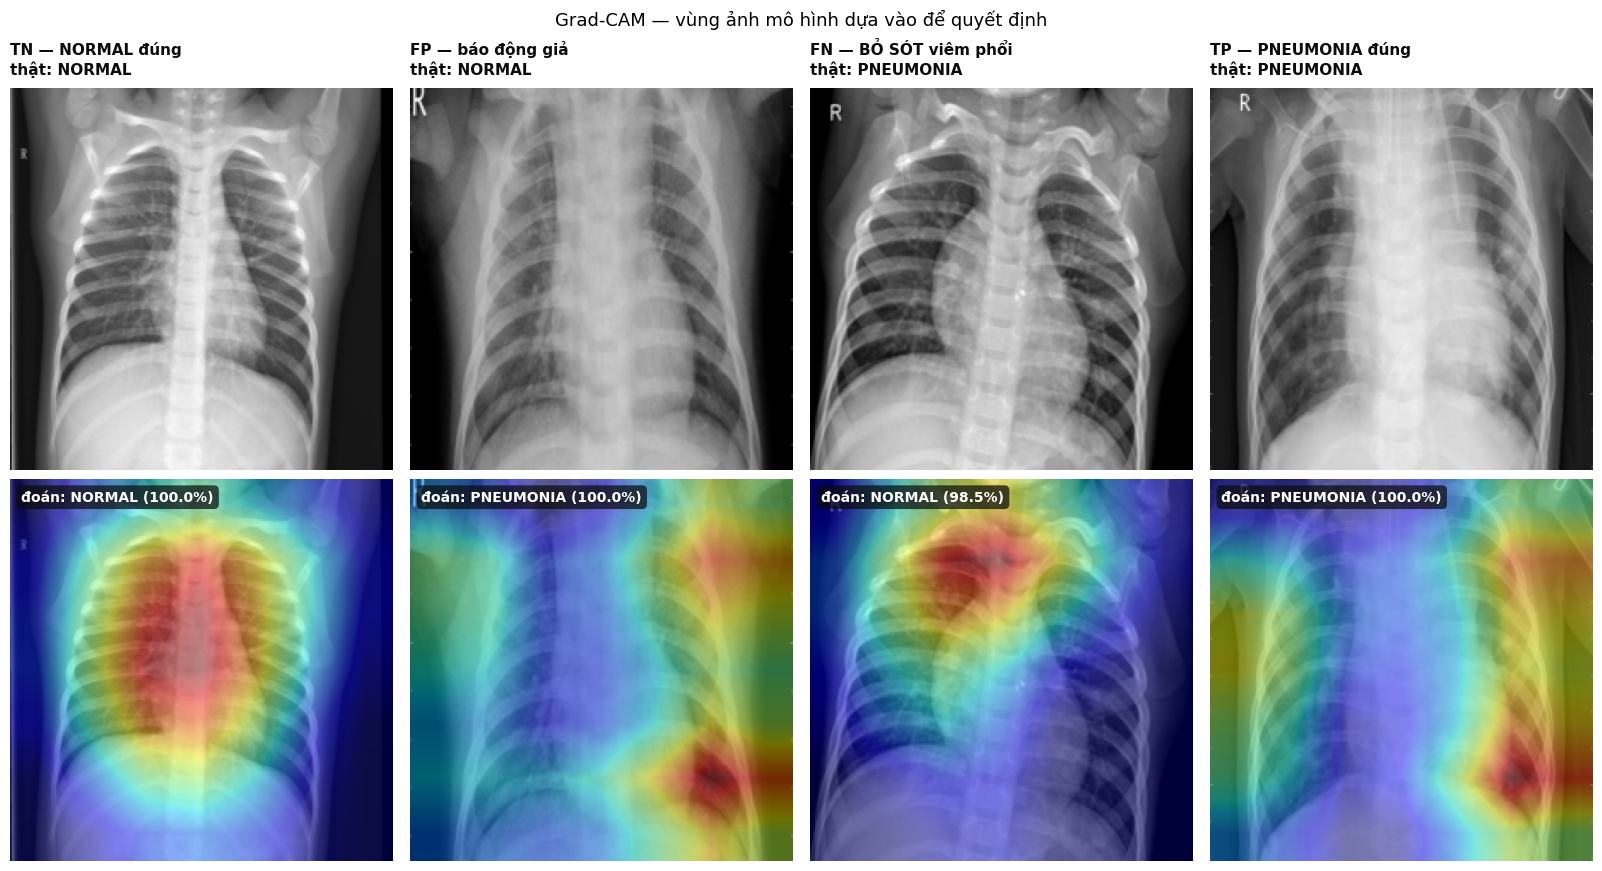

In [27]:
figure, axes = plt.subplots(2, len(picks), figsize=(4.0 * len(picks), 8.6),
                            constrained_layout=True)
axes = np.atleast_2d(axes)

for column, (name, row) in enumerate(picks.items()):
    tensor = model_input(row)
    cams, logits = cam_engine(tensor)
    probability = torch.softmax(logits.float(), 1)[0, int(row["pred"])].item()
    grayscale = denormalize(tensor[0])

    axes[0, column].imshow(grayscale, cmap="gray")
    axes[0, column].set_title(f"{name}\nthật: {CLASSES[row['true']]}",
                              fontsize=11, pad=10)
    axes[1, column].imshow(grayscale, cmap="gray")
    axes[1, column].imshow(cams[0], cmap="jet", alpha=0.45)
    axes[1, column].text(
        0.03, 0.97, f"đoán: {CLASSES[row['pred']]} ({probability:.1%})",
        transform=axes[1, column].transAxes, va="top", ha="left",
        fontsize=10, fontweight="600", color="white",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#0b0b0b",
                  alpha=0.72, edgecolor="none"))
    for axis in axes[:, column]:
        axis.axis("off")

figure.suptitle("Grad-CAM — vùng ảnh mô hình dựa vào để quyết định", fontsize=13)
plt.show()

## 4.3. Khối lượng nhiệt ở viền ảnh

Quan sát vài tấm bằng mắt dễ dẫn tới kết luận cảm tính. Phép đo dưới đây tính tỉ
lệ khối lượng nhiệt rơi vào **viền ngoài 15%** — vùng không thể chứa nhu mô phổi
— trên một mẫu ngẫu nhiên của tập test.

Mốc so sánh là chính tỉ lệ diện tích của viền: nếu nhiệt phân bố hoàn toàn ngẫu
nhiên, hai con số bằng nhau. Cao hơn mốc nghĩa là mô hình bám đặc trưng ngoài phổi.

In [28]:
def border_mass_fraction(cam, border=BORDER_FRAC):
    height, width = cam.shape
    margin_y, margin_x = int(height * border), int(width * border)
    interior = cam[margin_y:height - margin_y, margin_x:width - margin_x].sum()
    return float(1.0 - interior / (cam.sum() + 1e-8))


sample = test_rows.sample(n=min(120, len(test_rows)), random_state=SEED)
fractions = np.array([border_mass_fraction(cam_engine(model_input(row))[0][0])
                      for _, row in sample.iterrows()])
baseline = 1 - (1 - 2 * BORDER_FRAC) ** 2

print(f"n = {len(fractions)} ảnh test  |  viền ngoài {BORDER_FRAC:.0%}")
print(f"  trung vị       : {np.median(fractions):.1%}")
print(f"  trung bình     : {fractions.mean():.1%}")
print(f"  cao nhất       : {fractions.max():.1%}")
print(f"  mốc ngẫu nhiên : {baseline:.1%}")
print(f"  số ca vượt mốc : {(fractions > baseline).sum()}/{len(fractions)}")

n = 120 ảnh test  |  viền ngoài 15%
  trung vị       : 45.0%
  trung bình     : 42.6%
  cao nhất       : 59.5%
  mốc ngẫu nhiên : 51.0%
  số ca vượt mốc : 28/120


Nhiệt rơi vào viền **ít hơn** mức ngẫu nhiên: trung vị 45,0% so với mốc 51,0%, và
chỉ 28/120 ảnh vượt mốc. Ảnh cực đoan nhất cũng chỉ đạt 59,5%, tức vẫn quanh mức
ngẫu nhiên chứ không dồn hẳn ra ngoài.

Đây là kết quả **thuận lợi nhưng yếu**. Nó loại trừ trường hợp xấu nhất — mô hình
đọc chủ yếu từ viền, nơi có ký hiệu "R" và nhãn thiết bị — chứ không chứng minh
mô hình đọc dấu hiệu bệnh lý. Grad-CAM chỉ nói mô hình *nhìn* vào đâu; mục 4.4
mới hỏi vùng đó có *cần thiết* không.

Phạm vi: 120 ảnh, một fold, một mô hình.

## 4.4. Kiểm tra bằng cách che vùng

Bản đồ nhiệt cho biết mô hình *nhìn* vào đâu, nhưng không chứng minh vùng đó
*cần thiết* cho quyết định. Phép thử này can thiệp trực tiếp: che một vùng bằng
giá trị trung bình của ảnh rồi đo dự đoán thay đổi bao nhiêu.

- Che **viền ngoài 15%** — vùng không chứa phổi
- Che **vùng giữa** — nơi chứa nhu mô phổi

Nếu mô hình thật sự dùng dấu hiệu ở phổi, che vùng giữa phải làm dự đoán đổi
nhiều hơn hẳn so với che viền.

In [29]:
@torch.no_grad()
def probability_of(tensor):
    return torch.softmax(xai_model(tensor).float(), 1)[0, 1].item()


def occlude(tensor, region, border=BORDER_FRAC):
    """Che một vùng bằng giá trị trung bình của chính ảnh đó."""
    out = tensor.clone()
    _, _, height, width = out.shape
    my, mx = int(height * border), int(width * border)
    fill = out.mean()
    if region == "border":
        out[:, :, :my, :] = fill; out[:, :, height - my:, :] = fill
        out[:, :, :, :mx] = fill; out[:, :, :, width - mx:] = fill
    else:
        out[:, :, my:height - my, mx:width - mx] = fill
    return out


rows = []
for _, row in sample.iterrows():
    tensor = model_input(row)
    base = probability_of(tensor)
    rows.append({"base": base,
                 "Δ che viền":   abs(probability_of(occlude(tensor, "border")) - base),
                 "Δ che giữa":   abs(probability_of(occlude(tensor, "center")) - base)})
occlusion = pd.DataFrame(rows)

print(f"n = {len(occlusion)} ảnh test  |  thay đổi tuyệt đối của P(PNEUMONIA)\n")
display(occlusion[["Δ che viền", "Δ che giữa"]].describe().loc[
    ["mean", "50%", "max"]].round(4))

ratio = occlusion["Δ che giữa"].median() / max(occlusion["Δ che viền"].median(), 1e-6)
print(f"\ntỉ số trung vị (giữa / viền) = {ratio:.2f}")
print("  > 1 : che vùng phổi ảnh hưởng nhiều hơn — đúng kỳ vọng")
print("  ≈ 1 : hai vùng ảnh hưởng ngang nhau — mô hình không tập trung vào phổi")
print("  < 1 : viền ảnh hưởng nhiều hơn — dấu hiệu bám artifact")

cam_engine.close()

n = 120 ảnh test  |  thay đổi tuyệt đối của P(PNEUMONIA)



,Δ che viền,Δ che giữa
mean,0.2905,0.3088
50%,0.0029,0.0029
max,0.9989,0.9996



tỉ số trung vị (giữa / viền) = 0.98
  > 1 : che vùng phổi ảnh hưởng nhiều hơn — đúng kỳ vọng
  ≈ 1 : hai vùng ảnh hưởng ngang nhau — mô hình không tập trung vào phổi
  < 1 : viền ảnh hưởng nhiều hơn — dấu hiệu bám artifact


**Đọc con số nào.** Dòng `tỉ số trung vị = 0,98` mà cell in ra không dùng được:
cả hai trung vị đều bằng 0,0029, nghĩa là với quá nửa số ảnh, che vùng nào cũng
gần như không đổi gì dự đoán. Chia hai số sát 0 cho nhau chỉ ra nhiễu.

Phần có tín hiệu nằm ở trung bình: che vùng giữa đổi dự đoán **0,309**, che viền
đổi **0,291** — vùng phổi nhỉnh hơn 0,018 tuyệt đối, khoảng 6% tương đối. Hướng
đúng như kỳ vọng, nhưng biên độ quá nhỏ để nói mô hình dựa **chủ yếu** vào phổi.

Phân bố lệch rất mạnh (trung vị 0,003, cực đại 1,00) cho thấy hai nhóm ảnh khác
hẳn nhau: phần lớn mô hình quyết định chắc tới mức che gì cũng không lay chuyển,
một thiểu số thì đảo hoàn toàn. Trung bình gộp hai nhóm đó lại nên không đại diện
cho nhóm nào.

Kết luận đúng mức: phép thử này **chưa phân giải được** câu hỏi. Muốn trả lời cần
so theo cặp trên từng ảnh — phân bố của hiệu Δgiữa − Δviền kèm khoảng tin cậy —
thay vì đặt hai thống kê gộp cạnh nhau.

---

# 5. Kết luận và hạn chế

## Cách gọi tên kết quả

Khi trích dẫn số từ báo cáo này, ghi kèm nhãn để người đọc biết nó thuộc loại nào:

| Nhãn | Ý nghĩa | Có trong báo cáo này |
|---|---|---|
| `reproduced` | Nhóm chạy theo cấu hình đã ghi | ✅ toàn bộ phần 3 |
| `patient_grouped` | Chia dữ liệu chống rò rỉ bệnh nhân | ✅ mọi fold |
| `external` | Chạy trên nguồn dữ liệu khác | ❌ chưa có |
| `paper_reported` | Số do tài liệu gốc công bố | không áp dụng |

Không dùng các từ "trustworthy", "clinical-ready", "radiologist-level" khi chưa
có kiểm chứng lâm sàng bên ngoài.

## Đã làm được

- Pipeline chạy đầu-cuối, xử lý được các bất thường của bộ dữ liệu: hai kiểu
  đường dẫn mount, cây thư mục lồng trùng, file sidecar `._*`.
- Kiểm tra chất lượng dữ liệu có số liệu và tái chạy được.
- Chia theo bệnh nhân, xác nhận không bệnh nhân nào nằm ở hai split.
- Cross-validation nhiều fold, báo khoảng dao động thay vì một con số đơn lẻ.
- **So sánh ba kiến trúc và hai cách xử lý mất cân bằng**; hai backbone
  pretrained chạy dưới cùng giao thức, `small_cnn` là mốc tham chiếu (mục 2.4).
- Khôi phục checkpoint tốt nhất trước khi chấm test.
- Báo cáo cả **mức ảnh và mức bệnh nhân**, cả ngưỡng mặc định lẫn ngưỡng dò.
- Diễn giải bằng Grad-CAM, đo khối lượng nhiệt ở viền, và kiểm tra can thiệp
  bằng cách che vùng.
- Seed đầy đủ gồm cả DataLoader; ghi lại phiên bản thư viện vào `environment.json`.

## Hạn chế

- **Validation không phải proxy cho test** (mục 3.2). Chừng nào chưa giải thích
  được khoảng cách 0,994 → 0,820 ở balanced accuracy, mọi quyết định dựa vào
  val — chọn checkpoint, dò ngưỡng — đều kém tin cậy hơn vẻ ngoài của nó.
- **Việc chọn thí nghiệm tốt nhất ở mục 3.4 đọc điểm trên test.** Phần 4 vì thế
  diễn giải một mô hình được chọn hậu nghiệm, không phải mô hình mà quy trình mù
  sẽ chọn.
- **Kiểm trùng ảnh mới làm trên split gốc.** 30 nhóm ảnh trùng nội dung nằm gọn
  trong pool train+val chưa được kiểm lại sau khi chia 5 fold, nên chưa loại được
  khả năng hai bản sao rơi vào train và val của cùng một fold.
- **Ngưỡng dò ở mức ảnh được dùng lại cho mức bệnh nhân.** Lấy trung bình xác
  suất co phân bố về giữa, nên ngưỡng đó không còn là điểm tối ưu ở mức bệnh nhân.
- **`cnn_tu_dau` không tái hiện được cấu hình công khai** (accuracy 0,798 so với
  0,926 được báo cáo). Chưa truy được nguyên nhân, nên chưa dùng dòng này để kết
  luận gì về giá trị của pretrain.
- **Phép thử che vùng ở mục 4.4 chưa phân giải được**, xem phần đọc số ở đó.
- **So sánh giữa các thí nghiệm mới ở mức trung bình ± std.** Các fold là chung
  cho mọi thí nghiệm nên đúng ra phải so theo cặp trên từng fold; `results_per_fold.csv`
  có sẵn số để làm việc đó.
- **Chưa dò siêu tham số.** Learning rate, augmentation và kích thước ảnh đều để
  cố định; kết quả chưa phải giới hạn của các kiến trúc này.
- **Các fold đổi đồng thời cả cách chia lẫn seed**, nên `± std` là tổng của hai
  nguồn dao động, chưa tách riêng được. Muốn tách thì giữ nguyên một fold và đổi
  seed.
- **Chưa thử weighted sampler, focal loss hay SMOTE** — mới so weighted và
  unweighted cross-entropy.
- **Precision đo trên tập test có 62,5% ca bệnh**, cao hơn thực tế phòng khám, nên
  con số này không chuyển sang môi trường triển khai được.
- **Dữ liệu từ một trung tâm, chỉ gồm bệnh nhi 1–5 tuổi.** Không có cơ sở suy rộng
  sang người lớn hay cơ sở y tế khác nếu chưa kiểm chứng trên dữ liệu ngoài.
- **Nhãn nhị phân** không mô tả các bất thường khác có thể có trong nhóm bình thường.

## Hướng tiếp theo

1. **Truy khoảng cách val ↔ test.** Kiểm trùng ảnh lại trong từng fold rồi chạy
   lại: val F1 tụt bao nhiêu thì đúng bằng phần rò rỉ. Phần còn lại là lệch phân
   bố giữa pool và thư mục test gốc.
2. **Làm lại phép thử che vùng theo cặp**: lấy Δgiữa − Δviền trên từng ảnh kèm
   khoảng tin cậy, thay cho việc so hai thống kê gộp.
3. Đưa việc chọn thí nghiệm về phía validation, hoặc giữ nguyên và báo cáo nó
   như lựa chọn hậu nghiệm — không để lẫn hai cách.
4. Dò ngưỡng riêng ở mức bệnh nhân thay vì mượn ngưỡng của mức ảnh.
5. Kiểm chứng trên một bộ dữ liệu ngoài trước khi nói tới khả năng khái quát hoá.
6. Bổ sung weighted sampler và focal loss cho đủ nhóm thí nghiệm mất cân bằng.
7. Chạy 3 seed trên cùng một fold để tách dao động do seed khỏi dao động do chia dữ liệu.
8. Chọn điểm làm việc theo yêu cầu lâm sàng — ưu tiên độ nhạy nếu dùng để sàng lọc.

## Tệp xuất ra

| Tệp | Nội dung |
|---|---|
| `train_log.txt` | Nhật ký huấn luyện đầy đủ |
| `results_per_fold.csv` | Chỉ số từng fold, cả mức ảnh và mức bệnh nhân |
| `manifest_fold*.csv` | Danh sách ảnh chính xác của từng fold |
| `environment.json` | Phiên bản thư viện, GPU, seed |
| `*_fold*.pth` | Trọng số tốt nhất của từng thí nghiệm × fold |

Đính kèm `manifest_fold*.csv` và `environment.json` khi nộp để người đọc truy
ngược được đúng danh sách ảnh và đúng môi trường đứng sau mỗi con số.